# Taiwan Next-Quarter Interest Rate Forecasting Model

**Research objective** — Use Taiwan quarterly macroeconomic indicators to forecast the
central bank (CBC) policy *benchmark* interest rate **one quarter ahead**, and compare the
**out-of-sample** performance of linear and non-linear regression models.

Given information available in quarter $t$ (macro indicators for $t$ and the current policy
rate), predict the policy rate in quarter $t+1$.

### Scope and disclaimers

- This notebook does **regression only**, and the target is the **next-quarter rate level**
  ($Rate_{t+1}$) — predicted directly, not as a change.
- It does **not** build a hike / cut / hold **classification** model. There is no "Task 2".
- **Directional accuracy** (did the model get the sign of the rate move right?) is reported
  only as a *supplementary diagnostic* for the regression, not as a classification metric.
- All results are **predictive associations**, not causal effects.
- Nothing here is investment advice.

### How to read this notebook

Every major section has: a heading, a short method note, runnable code, a table or figure,
and a Markdown interpretation of what the result means and its limitations. The notebook is
designed to run top-to-bottom via **Restart Kernel → Run All** with no hidden state.

## 1. Imports and Configuration

All packages and **all tunable parameters** are collected here so nothing important is
hard-coded further down. XGBoost and SHAP are optional: if a package is missing the notebook
skips it gracefully and never auto-installs anything.

In [1]:
import os
# single-threaded numeric backends: reproducible, and avoids thread oversubscription
# when fitting many tiny models in cross-validation
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "BLIS_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import re
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor)
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---- optional dependencies -------------------------------------------------
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

print("xgboost available:", HAS_XGB, "| shap available:", HAS_SHAP)

# ---- global config -------------------------------------------------------
RANDOM_STATE          = 42
CORRELATION_THRESHOLD = 0.80     # |Pearson r| flagged as a collinear pair
VIF_THRESHOLD         = 10.0     # VIF above this = high multicollinearity
TEST_SIZE_RATIO       = 0.20     # final holdout = last 20% of the timeline
N_TIME_SPLITS         = 5        # expanding-window CV folds inside the training block

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")
try:
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
except Exception:
    pass

# ---- plotting style ----------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"]   = (11, 5)
plt.rcParams["figure.dpi"]       = 110
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.sans-serif"]  = ["Microsoft JhengHei", "Microsoft YaHei",
                                    "DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False

xgboost available: True | shap available: True


### 1.1 Reusable helper functions

- `regression_metrics` — MAE, RMSE, $R^2$ and directional accuracy, all computed on the
  **predicted next-quarter rate** so level-target and change-target models are compared on
  the same scale.
- `directional_accuracy` — share of quarters where the model got the *sign* of the rate move right.
- `calculate_vif` — Variance Inflation Factor table (numeric-only, drops inf/NaN and
  near-constant columns, standardizes first for numerical stability; VIF itself is scale-invariant).

In [2]:
def directional_accuracy(actual_next, pred_next, current) -> float:
    """Share of points where sign(pred - current) == sign(actual - current)."""
    a = np.sign(np.round(np.asarray(actual_next, float) - np.asarray(current, float), 6))
    p = np.sign(np.round(np.asarray(pred_next, float)  - np.asarray(current, float), 6))
    return float(np.mean(a == p))


def regression_metrics(actual_next, pred_next, current) -> dict:
    """All metrics on the predicted *next-quarter rate* scale."""
    actual_next = np.asarray(actual_next, float)
    pred_next   = np.asarray(pred_next, float)
    current     = np.asarray(current, float)
    out = {
        "MAE":  mean_absolute_error(actual_next, pred_next),
        "RMSE": float(np.sqrt(mean_squared_error(actual_next, pred_next))),
        "R2":   r2_score(actual_next, pred_next) if len(actual_next) > 1 else np.nan,
        "DirAcc": directional_accuracy(actual_next, pred_next, current),
    }
    return out


def calculate_vif(X: pd.DataFrame) -> pd.DataFrame:
    """Variance Inflation Factor for every numeric column of X."""
    Xn = X.select_dtypes(include=[np.number]).copy()
    Xn = Xn.replace([np.inf, -np.inf], np.nan).dropna()
    non_constant = Xn.columns[Xn.std(ddof=0) > 1e-10]
    Xn = Xn[non_constant]
    Xs = pd.DataFrame(StandardScaler().fit_transform(Xn), columns=Xn.columns)
    Xc = sm.add_constant(Xs, has_constant="add")
    rows = []
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        rows.append({"feature": col,
                     "VIF": float(variance_inflation_factor(Xc.values, i))})
    return (pd.DataFrame(rows)
              .sort_values("VIF", ascending=False)
              .reset_index(drop=True))


def vif_flag(v: float) -> str:
    if v < 5:   return "ok (<5)"
    if v < 10:  return "watch (5-10)"
    return "high (>10)"

## 2. Load and Validate Data

We load `taiwan_rate_model_dataset.csv` with `utf-8-sig` (handles the BOM), resolve the path
relatively so the notebook works after a GitHub checkout, then run a full battery of
structural checks: shape, dtypes, missing values, duplicate quarters, ordering, date range,
frequency, infinities, and descriptive statistics.

**Column meaning.** `Y_基準利率` is the CBC benchmark rate (%). The `X<n>` columns are quarterly
macro indicators and the `X<a>_X<b>` columns are interaction (product) terms. The interaction
set is **not fixed**: the feature-engineering step (`Taiwan-interest-rate.ipynb`) screens the
Pearson correlations among the base predictors and keeps a product term only for **low-correlation
pairs** (so the interaction carries genuinely new information and is not near-collinear with its
parents). This notebook derives `BASE_X` / `RAW_INT` from the CSV header, so it adapts if that
screen changes. The base-predictor definitions below are for context only — nothing in the code
relies on them.

### 變數中文對照 (variable dictionary)

| 欄位 | 中文名稱 | 說明 |
|---|---|---|
| `Y_基準利率` | 台灣央行基準利率 | 央行政策利率（重貼現率），單位 %；季底生效值 |
| `current_rate` | 當季基準利率 | = 當季的 `Y_基準利率`，當作特徵使用（利率有高度持續性） |
| `next_rate` | 下一季基準利率 | **預測目標** $Rate_{t+1}$ |
| `next_rate_change` | 下一季利率變動 | $Rate_{t+1}-Rate_t$；僅供方向性正確率、EDA 用，**非**建模目標 |
| `X1` | 實質 GDP 年增率 | 實質 GDP YoY%（連鎖實質值） |
| `X2` | 季核心 CPI 年增率 | 核心消費者物價指數 YoY%，季平均 |
| `X3` | 進口物價指數年增率 | 進口物價指數 YoY%，季平均 |
| `X4` | 季 M2 貨幣供給年增率 | 廣義貨幣 M2 YoY%，季平均 |
| `X5` | 季消費者房貸餘額年增率 | 消費者購置住宅貸款餘額 YoY%，季平均 |
| `X6` | 季零售銷售額年增率 | 零售銷售額 YoY%，季平均（新增） |
| `X<a>_X<b>` | 交互作用項 | = `X<a> × X<b>`；只對「相關係數低」的變數配對建立（見特徵工程步驟） |


In [3]:
PROJECT_DIR = Path.cwd()
DATA_PATH   = PROJECT_DIR / "taiwan_rate_model_dataset.csv"

FALLBACK_PROJECT_DIR = Path(
    r"C:\Users\Kai_R\Desktop\元大\產業研究組\國家報告\taiwan-interest-rate-forecast"
)

def resolve_data_path() -> Path:
    candidates = [
        PROJECT_DIR / "taiwan_rate_model_dataset.csv",
        PROJECT_DIR / "Data" / "taiwan_rate_model_dataset.csv",
        FALLBACK_PROJECT_DIR / "taiwan_rate_model_dataset.csv",
        FALLBACK_PROJECT_DIR / "Data" / "taiwan_rate_model_dataset.csv",
    ]
    for c in candidates:
        if c.exists():
            return c
    # last resort: search the project tree
    for base in (PROJECT_DIR, FALLBACK_PROJECT_DIR):
        hits = list(base.rglob("taiwan_rate_model_dataset.csv"))
        if hits:
            return hits[0]
    raise FileNotFoundError(
        "taiwan_rate_model_dataset.csv not found under "
        f"{PROJECT_DIR} or {FALLBACK_PROJECT_DIR}"
    )

DATA_PATH = resolve_data_path()
print("Using data file:", DATA_PATH)

raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
raw.head()

Using data file: C:\Users\Kai_R\Desktop\元大\產業研究組\國家報告\taiwan-interest-rate-forecast\Data\taiwan_rate_model_dataset.csv


,年季,Y_基準利率,X1,X2,X3,X4,X5,X6,X1_X4,X1_X2,X2_X4,X2_X3,X2_X5,X3_X4,X4_X6,X2_X6,X3_X5,X3_X6,X1_X3
0,2001Q3,2.750,-4.064,-0.323333,-0.581667,6.476667,3.070583,-3.690000,-26.321173,1.314027,-2.094122,0.188072,-0.992822,-3.767261,-23.898900,1.193100,-1.786056,2.146350,2.363893
1,2001Q4,2.125,-0.302,-0.603333,-1.587667,5.600000,0.629032,-3.400000,-1.691200,0.182207,-3.378667,0.957892,-0.379516,-8.890933,-19.040000,2.051333,-0.998693,5.398067,0.479475
2,2002Q1,2.125,1.823,0.466667,0.509667,4.030000,-0.787850,1.946667,7.346690,0.850733,1.880667,0.237844,-0.367663,2.053957,7.845067,0.908444,-0.401541,0.992151,0.929122
3,2002Q2,1.875,6.751,0.656667,0.468000,4.286667,-0.126594,3.796667,28.939287,4.433157,2.814911,0.307320,-0.083130,2.006160,16.275044,2.493144,-0.059246,1.776840,3.159468
4,2002Q3,1.875,7.025,0.770000,0.493333,2.956667,1.582225,5.733333,20.770583,5.409250,2.276633,0.379867,1.218314,1.458622,16.951556,4.414667,0.780565,2.828444,3.465667


In [4]:
# ---------- structural validation ----------------------------------------
report = {}
report["shape"]                = raw.shape
report["columns"]              = list(raw.columns)
report["n_missing_cells"]      = int(raw.isna().sum().sum())
report["has_inf"]              = bool(np.isinf(raw.select_dtypes(np.number).to_numpy()).any())
report["n_duplicate_年季"]      = int(raw["年季"].duplicated().sum())

q = pd.PeriodIndex(raw["年季"].astype(str), freq="Q")
report["first_quarter"]        = str(q.min())
report["last_quarter"]         = str(q.max())
report["is_sorted_ascending"]  = bool((q == q.sort_values()).all())
step_counts = pd.Series(np.diff(q.asi8)).value_counts().to_dict()
report["quarter_step_counts"]  = step_counts    # {1: n} => strictly quarterly

for k, v in report.items():
    print(f"{k:22s}: {v}")

print("\ndtypes:")
print(raw.dtypes)
print("\nmissing values by column:")
print(raw.isna().sum())

shape                 : (100, 19)
columns               : ['年季', 'Y_基準利率', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X1_X4', 'X1_X2', 'X2_X4', 'X2_X3', 'X2_X5', 'X3_X4', 'X4_X6', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']
n_missing_cells       : 0
has_inf               : False
n_duplicate_年季        : 0
first_quarter         : 2001Q3
last_quarter          : 2026Q2
is_sorted_ascending   : True
quarter_step_counts   : {1: 99}

dtypes:
年季         object
Y_基準利率    float64
X1        float64
X2        float64
X3        float64
X4        float64
X5        float64
X6        float64
X1_X4     float64
X1_X2     float64
X2_X4     float64
X2_X3     float64
X2_X5     float64
X3_X4     float64
X4_X6     float64
X2_X6     float64
X3_X5     float64
X3_X6     float64
X1_X3     float64
dtype: object

missing values by column:
年季        0
Y_基準利率    0
X1        0
X2        0
X3        0
X4        0
X5        0
X6        0
X1_X4     0
X1_X2     0
X2_X4     0
X2_X3     0
X2_X5     0
X3_X4     0
X4_X6     0
X2_X6     0
X

In [5]:
print("First 5 rows:"); display(raw.head())
print("Last 5 rows:");  display(raw.tail())
print("\nDescriptive statistics (numeric columns):")
raw.describe().T.round(3)

First 5 rows:


,年季,Y_基準利率,X1,X2,X3,X4,X5,X6,X1_X4,X1_X2,X2_X4,X2_X3,X2_X5,X3_X4,X4_X6,X2_X6,X3_X5,X3_X6,X1_X3
0,2001Q3,2.750,-4.064,-0.323333,-0.581667,6.476667,3.070583,-3.690000,-26.321173,1.314027,-2.094122,0.188072,-0.992822,-3.767261,-23.898900,1.193100,-1.786056,2.146350,2.363893
1,2001Q4,2.125,-0.302,-0.603333,-1.587667,5.600000,0.629032,-3.400000,-1.691200,0.182207,-3.378667,0.957892,-0.379516,-8.890933,-19.040000,2.051333,-0.998693,5.398067,0.479475
2,2002Q1,2.125,1.823,0.466667,0.509667,4.030000,-0.787850,1.946667,7.346690,0.850733,1.880667,0.237844,-0.367663,2.053957,7.845067,0.908444,-0.401541,0.992151,0.929122
3,2002Q2,1.875,6.751,0.656667,0.468000,4.286667,-0.126594,3.796667,28.939287,4.433157,2.814911,0.307320,-0.083130,2.006160,16.275044,2.493144,-0.059246,1.776840,3.159468
4,2002Q3,1.875,7.025,0.770000,0.493333,2.956667,1.582225,5.733333,20.770583,5.409250,2.276633,0.379867,1.218314,1.458622,16.951556,4.414667,0.780565,2.828444,3.465667


Last 5 rows:


,年季,Y_基準利率,X1,X2,X3,X4,X5,X6,X1_X4,X1_X2,X2_X4,X2_X3,X2_X5,X3_X4,X4_X6,X2_X6,X3_X5,X3_X6,X1_X3
95,2025Q2,2.0,7.705,1.580000,-0.188333,3.606667,8.719529,-1.330000,27.789367,12.173900,5.698533,-0.297567,13.776855,-0.679256,-4.796867,-2.101400,-1.642178,0.250483,-1.451108
96,2025Q3,2.0,8.417,1.633333,0.000000,4.066667,6.801323,-2.610000,34.229133,13.747767,6.642222,0.000000,11.108828,0.000000,-10.614000,-4.263000,0.000000,-0.000000,0.000000
97,2025Q4,2.0,12.952,1.790000,-3.666000,5.240000,5.109925,0.213333,67.868480,23.184080,9.379600,-6.562140,9.146765,-19.209840,1.117867,0.381867,-18.732984,-0.782080,-47.482032
98,2026Q1,2.0,15.426,1.933333,0.795333,5.426667,4.501858,-0.323333,83.711760,29.823600,10.491556,1.537644,8.703593,4.316009,-1.754622,-0.625111,3.580478,-0.257158,12.268812
99,2026Q2,2.0,12.929,2.153333,1.233667,7.143333,4.436409,5.406667,92.356157,27.840447,15.381978,2.656496,9.553068,8.812492,38.621622,11.642356,5.473050,6.670024,15.950076



Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
Y_基準利率,100.0,1.802,0.557,1.125,1.375,1.875,2.000,3.625
X1,100.0,4.199,3.953,-7.872,2.153,4.197,6.399,15.426
X2,100.0,1.086,0.919,-0.837,0.571,0.913,1.587,3.937
X3,100.0,0.114,1.108,-5.980,-0.291,0.239,0.529,2.910
X4,100.0,5.288,1.670,1.423,3.950,5.435,6.467,8.970
X5,100.0,6.164,3.472,-0.788,4.180,5.064,8.016,15.492
X6,100.0,2.853,4.313,-7.007,0.429,2.840,5.407,16.223
X1_X4,100.0,22.199,24.567,-53.792,9.786,21.548,33.534,92.356
X1_X2,100.0,4.576,6.973,-19.989,1.154,3.534,6.921,29.824
X2_X4,100.0,5.722,5.410,-7.048,2.697,4.389,7.998,21.049


In [6]:
# ---------- build the working frame -------------------------------------
df = raw.copy()
df["quarter"]       = pd.PeriodIndex(df["年季"].astype(str), freq="Q")
df["quarter_label"] = df["年季"].astype(str)
df = df.sort_values("quarter").reset_index(drop=True)
df["quarter_ts"]    = df["quarter"].dt.to_timestamp(how="end")

assert df["quarter"].is_monotonic_increasing, "quarters not sorted"
assert df["quarter"].duplicated().sum() == 0, "duplicate quarters present"
assert (np.diff(pd.PeriodIndex(df["quarter"]).asi8) == 1).all(), \
    "timeline has gaps - not strictly quarterly"

RATE_COL = "Y_基準利率"
# Feature lists are DERIVED from the CSV columns, so this notebook automatically tracks
# whatever the feature-engineering step (Taiwan-interest-rate.ipynb) produced:
#   base predictors  -> columns named  X<n>      (X1, X2, ... X6, ...)
#   interaction terms -> columns named X<a>_X<b> (a low-correlation-screened set)
BASE_X    = [c for c in df.columns if re.fullmatch(r"X\d+", c)]
RAW_INT   = [c for c in df.columns if re.fullmatch(r"X\d+_X\d+", c)]
INT_PAIRS = [tuple(c.split("_")) for c in RAW_INT]

print(f"Working frame: {df.shape[0]} quarters, {df['quarter_label'].iloc[0]} -> {df['quarter_label'].iloc[-1]}")
print(f"BASE_X  ({len(BASE_X)}) : {BASE_X}")
print(f"RAW_INT ({len(RAW_INT)}): {RAW_INT}")
print("No missing values:", df[[RATE_COL] + BASE_X + RAW_INT].isna().sum().sum() == 0)

Working frame: 100 quarters, 2001Q3 -> 2026Q2
BASE_X  (6) : ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
RAW_INT (11): ['X1_X4', 'X1_X2', 'X2_X4', 'X2_X3', 'X2_X5', 'X3_X4', 'X4_X6', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']
No missing values: True


**Interpretation.** The dataset is a clean, gap-free quarterly panel (one row per quarter,
strictly spaced one quarter apart, sorted ascending, no missing values, no infinities, no
duplicate quarters). Descriptive statistics show the policy rate has a **narrow range and low
variance** — it is a highly persistent, slow-moving series that often stays flat for many
quarters. That single fact drives most modelling choices below: the hard part is not fitting
the level, it is beating a "rate stays the same" baseline.

## 3. Define the Forecasting Target

**The target is the next quarter's policy-rate level, $Rate_{t+1}$ — predicted directly.**
Models do **not** predict the quarter-on-quarter change; every model regresses on $Rate_{t+1}$
and is scored on that level (`predicted_next_rate`).

`next_rate_change` ($= Rate_{t+1} - Rate_t$) is still computed, but only as a helper for
**directional accuracy** (did the model get the sign of the move right?) and for the EDA
scatter plots — it is never a model target.

The **last row has no observed $Rate_{t+1}$**, so it is removed from the supervised dataset
and kept aside; the chosen model produces the genuine next-quarter forecast from it in
Section 16. An assertion checks that every feature value comes from quarter $t$ (or earlier)
and that the target is strictly the following quarter's rate — i.e. no target leakage.

In [7]:
df["current_rate"]     = df[RATE_COL].astype(float)
df["next_rate"]        = df[RATE_COL].shift(-1)
df["next_rate_change"] = df["next_rate"] - df["current_rate"]

FEAT_COLS = ["current_rate"] + BASE_X + RAW_INT   # master feature list (raw)

# leakage guard: next_rate[i] must equal current_rate[i+1]
chk = df["next_rate"].to_numpy()[:-1]
assert np.allclose(chk, df["current_rate"].to_numpy()[1:]), "target misaligned"
assert "next_rate" not in FEAT_COLS and "next_rate_change" not in FEAT_COLS
assert all(c in df.columns for c in FEAT_COLS)

supervised = df[df["next_rate"].notna()].reset_index(drop=True)     # rows we can train/score on
latest_row = df[df["next_rate"].isna()].reset_index(drop=True)      # 1 row -> genuine forecast input
assert len(latest_row) == 1

X_all    = supervised[FEAT_COLS].astype(float).copy()
y_level  = supervised["next_rate"].astype(float).copy()          # <-- the target
y_change = supervised["next_rate_change"].astype(float).copy()    # helper only (DirAcc / EDA), not a target
cur_all  = supervised["current_rate"].astype(float).copy()
q_all    = supervised["quarter"].copy()

print(f"Supervised rows : {len(supervised)}  ({supervised['quarter_label'].iloc[0]} -> {supervised['quarter_label'].iloc[-1]})")
print(f"Held-out latest : {latest_row['quarter_label'].iloc[0]} (features only, no target)")
print(f"Feature columns : {FEAT_COLS}")
display(supervised[["quarter_label", "current_rate", "next_rate", "next_rate_change"]].head())

Supervised rows : 99  (2001Q3 -> 2026Q1)
Held-out latest : 2026Q2 (features only, no target)
Feature columns : ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X1_X4', 'X1_X2', 'X2_X4', 'X2_X3', 'X2_X5', 'X3_X4', 'X4_X6', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']


,quarter_label,current_rate,next_rate,next_rate_change
0,2001Q3,2.750,2.125,-0.625
1,2001Q4,2.125,2.125,0.000
2,2002Q1,2.125,1.875,-0.250
3,2002Q2,1.875,1.875,0.000
4,2002Q3,1.875,1.625,-0.250


**Interpretation.** We have a small supervised sample (~1e2 quarters). `next_rate_change` is
zero in many quarters (the rate is unchanged) — so directional accuracy must be read
carefully: predicting "no change" is correct most of the time, which flatters both the
baseline and any model that barely moves.

## 4. Historical Rate Analysis

We plot the policy-rate path, mark the three well-known tightening environments
(2004–2008, 2010–2011, 2021–2023), and *derive* hike / cut / hold quarters directly from the
sign of the actual quarter-on-quarter rate change. These cycle labels are used **only for
description and later error analysis — never as model features.**

In [8]:
HIKE_ENVIRONMENTS = {
    "2004-2008": ("2004Q1", "2008Q4"),
    "2010-2011": ("2010Q1", "2011Q4"),
    "2021-2023": ("2021Q1", "2023Q4"),
}

rate_move = df[RATE_COL].diff()
df["rate_direction"] = np.select(
    [rate_move > 1e-9, rate_move < -1e-9],
    ["hike", "cut"], default="hold",
)
df.loc[0, "rate_direction"] = "n/a"

dir_counts = (df.loc[df["rate_direction"] != "n/a", "rate_direction"]
                .value_counts()
                .reindex(["hike", "cut", "hold"]).fillna(0).astype(int)
                .rename_axis("direction").reset_index(name="quarters"))
print("Quarter-on-quarter rate direction counts:")
display(dir_counts)

extra_2024 = df.loc[df["quarter_label"].isin(["2024Q1", "2024Q2", "2024Q3", "2024Q4"])]
print("\n2024 quarters (note the March-2024 CBC hike to 2.00%):")
display(extra_2024[["quarter_label", RATE_COL, "rate_direction"]])

Quarter-on-quarter rate direction counts:


,direction,quarters
0,hike,25
1,cut,12
2,hold,62



2024 quarters (note the March-2024 CBC hike to 2.00%):


,quarter_label,Y_基準利率,rate_direction
90,2024Q1,2.0,hike
91,2024Q2,2.0,hold
92,2024Q3,2.0,hold
93,2024Q4,2.0,hold


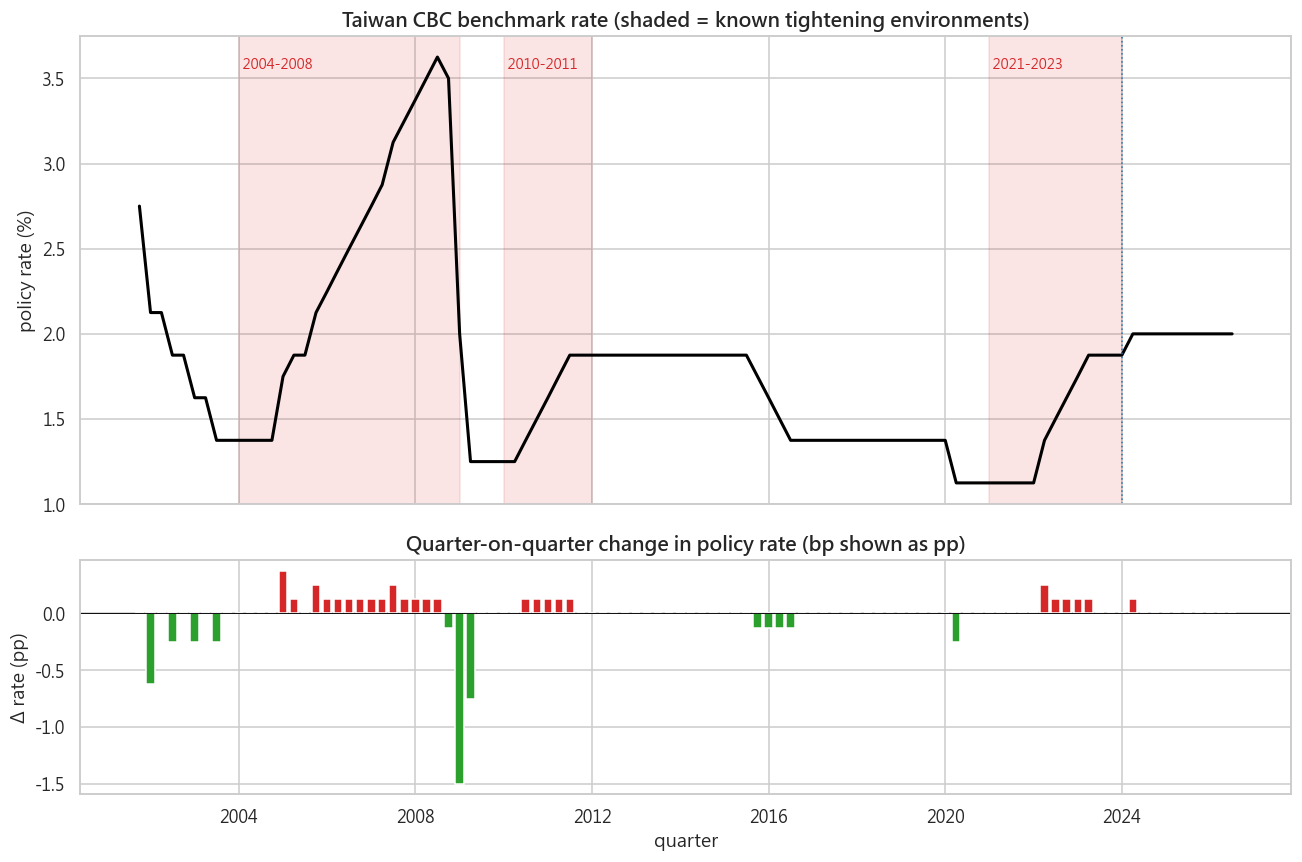

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(df["quarter_ts"], df[RATE_COL], color="black", lw=2)
for name, (a, b) in HIKE_ENVIRONMENTS.items():
    axes[0].axvspan(pd.Period(a, "Q").to_timestamp(),
                    pd.Period(b, "Q").to_timestamp(how="end"),
                    color="tab:red", alpha=0.12)
    axes[0].text(pd.Period(a, "Q").to_timestamp(), df[RATE_COL].max(), " " + name,
                 va="top", ha="left", fontsize=9, color="tab:red")
axes[0].axvline(pd.Period("2024Q1", "Q").to_timestamp(), color="tab:blue", ls=":", lw=1)
axes[0].set_title("Taiwan CBC benchmark rate (shaded = known tightening environments)")
axes[0].set_ylabel("policy rate (%)")

colors = df["rate_direction"].map({"hike": "tab:red", "cut": "tab:green",
                                   "hold": "lightgrey", "n/a": "white"})
axes[1].bar(df["quarter_ts"], rate_move.fillna(0), width=70, color=colors)
axes[1].axhline(0, color="black", lw=.6)
axes[1].set_title("Quarter-on-quarter change in policy rate (bp shown as pp)")
axes[1].set_ylabel("Δ rate (pp)")
axes[1].set_xlabel("quarter")
plt.tight_layout(); plt.show()

In [10]:
cyc_rows = []
for name, (a, b) in HIKE_ENVIRONMENTS.items():
    m = (df["quarter"] >= pd.Period(a, "Q")) & (df["quarter"] <= pd.Period(b, "Q"))
    seg = df.loc[m]
    cyc_rows.append({
        "cycle": name,
        "quarters": int(m.sum()),
        "rate_start": seg[RATE_COL].iloc[0],
        "rate_end": seg[RATE_COL].iloc[-1],
        "net_change_pp": round(seg[RATE_COL].iloc[-1] - seg[RATE_COL].iloc[0], 3),
        "n_hikes": int((seg["rate_direction"] == "hike").sum()),
        "n_cuts": int((seg["rate_direction"] == "cut").sum()),
        "n_holds": int((seg["rate_direction"] == "hold").sum()),
    })
cycle_summary = pd.DataFrame(cyc_rows)
cycle_summary

,cycle,quarters,rate_start,rate_end,net_change_pp,n_hikes,n_cuts,n_holds
0,2004-2008,20,1.375,2.000,0.625,14,2,4
1,2010-2011,8,1.250,1.875,0.625,5,0,3
2,2021-2023,12,1.125,1.875,0.750,5,0,7


**Interpretation.** The rate path is dominated by long flat stretches punctuated by a few
directional episodes. Hold quarters vastly outnumber hikes and cuts. The 2004–2008 tightening
is the largest and cleanest run of consecutive hikes; 2010–2011 is a short partial
normalisation after the GFC cuts; 2021–2023 is the post-pandemic tightening, and the data
also shows an **additional hike in 2024Q1** (to 2.00%) outside the labelled windows. Any
forecasting model will be judged mainly on whether it can anticipate these sparse turning
points rather than the (easy) flat periods.

## 5. Exploratory Data Analysis

Descriptive stats, per-feature time series, distributions, boxplots, an explicit outlier
scan, feature-vs-target scatter plots for **both** targets, and Pearson & Spearman
correlation matrices. Outliers are **identified and discussed, not deleted** — none are
demonstrably data errors, and with a sample this small every observation matters.

In [11]:
eda_cols = BASE_X + RAW_INT
supervised[eda_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
X1,99.0,4.111,3.873,-7.872,2.128,4.159,6.280,15.426
X2,99.0,1.076,0.918,-0.837,0.568,0.907,1.583,3.937
X3,99.0,0.102,1.108,-5.980,-0.295,0.238,0.509,2.910
X4,99.0,5.270,1.668,1.423,3.920,5.427,6.405,8.970
X5,99.0,6.182,3.485,-0.788,4.138,5.110,8.185,15.492
X6,99.0,2.827,4.327,-7.007,0.402,2.813,5.312,16.223
X1_X4,99.0,21.490,23.643,-53.792,9.612,20.771,33.026,88.012
X1_X2,99.0,4.341,6.599,-19.989,1.147,3.530,6.879,29.824
X2_X4,99.0,5.625,5.348,-7.048,2.580,4.276,7.862,21.049
X2_X3,99.0,0.016,2.432,-16.247,-0.298,0.133,0.525,10.273


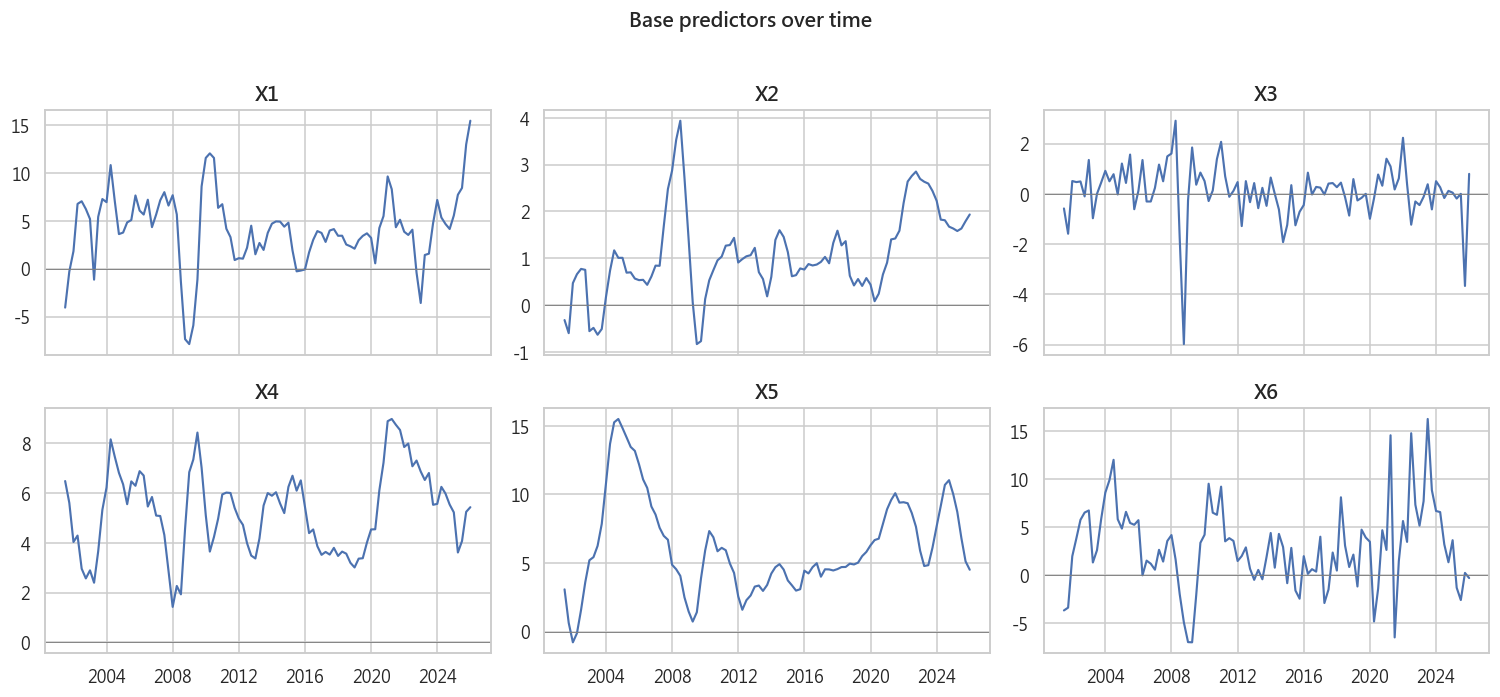

In [12]:
_ncol = 3
_nrow = int(np.ceil(len(BASE_X) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(4.6 * _ncol, 3.1 * _nrow), sharex=True)
axs = np.atleast_1d(axes).ravel()
for k, cname in enumerate(BASE_X):
    axs[k].plot(supervised["quarter"].dt.to_timestamp(), supervised[cname], lw=1.4)
    axs[k].axhline(0, color="grey", lw=.6)
    axs[k].set_title(cname)
for k in range(len(BASE_X), len(axs)):
    axs[k].axis("off")
fig.suptitle("Base predictors over time", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

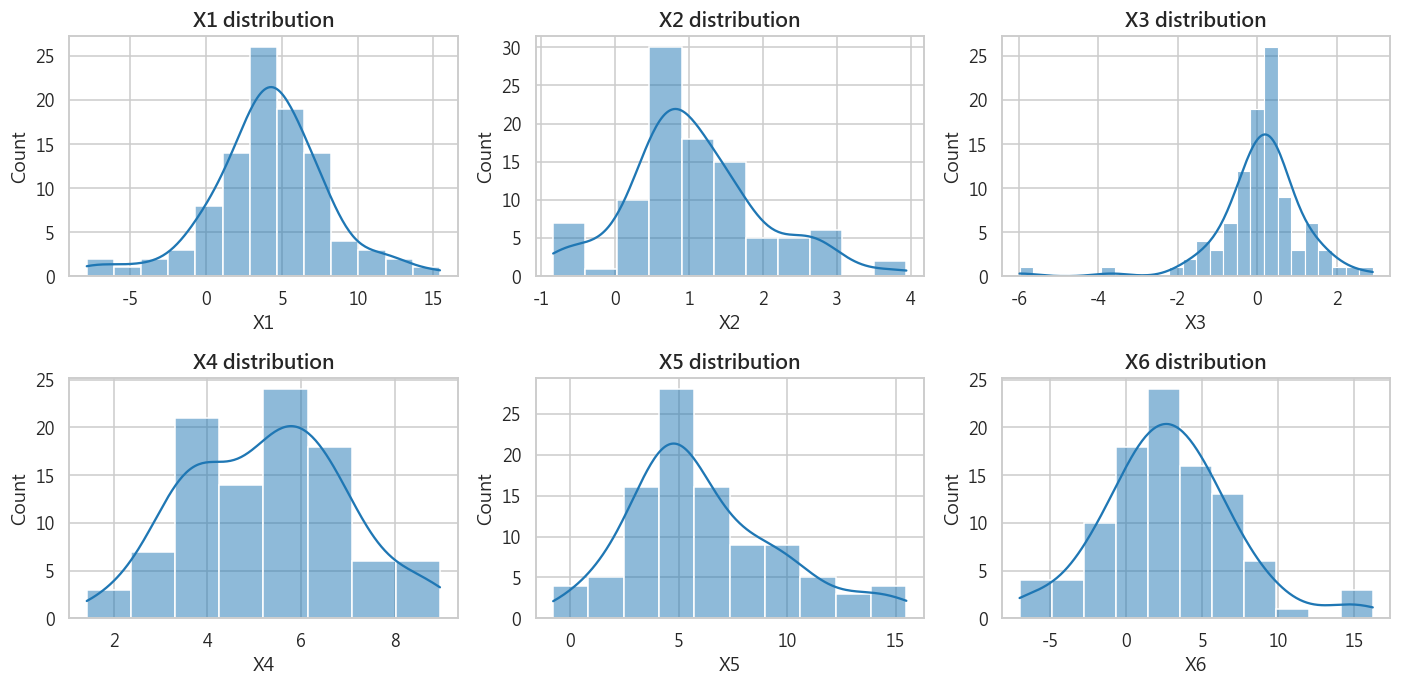

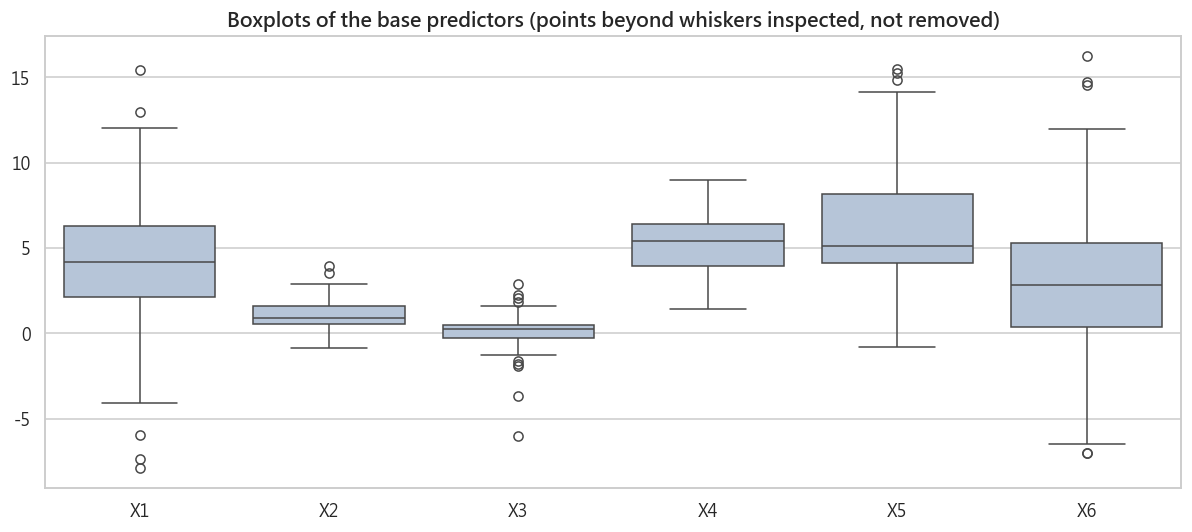

In [13]:
_ncol = 3
_nrow = int(np.ceil(len(BASE_X) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(4.3 * _ncol, 3.2 * _nrow))
axs = np.atleast_1d(axes).ravel()
for k, cname in enumerate(BASE_X):
    sns.histplot(supervised[cname], kde=True, ax=axs[k], color="tab:blue")
    axs[k].set_title(f"{cname} distribution")
for k in range(len(BASE_X), len(axs)):
    axs[k].axis("off")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=supervised[BASE_X], ax=ax, color="lightsteelblue")
ax.set_title("Boxplots of the base predictors (points beyond whiskers inspected, not removed)")
plt.tight_layout(); plt.show()

In [14]:
def iqr_outliers(s: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = s.quantile([0.25, 0.75])
    lo, hi = q1 - k * (q3 - q1), q3 + k * (q3 - q1)
    return (s < lo) | (s > hi)

outlier_tbl = []
for c in BASE_X + RAW_INT:
    mask = iqr_outliers(supervised[c])
    outlier_tbl.append({
        "feature": c,
        "n_outliers": int(mask.sum()),
        "outlier_quarters": ", ".join(supervised.loc[mask, "quarter_label"].tolist()[:8]),
    })
pd.DataFrame(outlier_tbl)

,feature,n_outliers,outlier_quarters
0,X1,5,"2008Q4, 2009Q1, 2009Q2, 2025Q4, 2026Q1"
1,X2,2,"2008Q2, 2008Q3"
2,X3,9,"2001Q4, 2008Q2, 2008Q3, 2008Q4, 2009Q2, 2011Q1..."
3,X4,0,
4,X5,3,"2004Q3, 2004Q4, 2005Q1"
5,X6,5,"2009Q1, 2009Q2, 2021Q2, 2022Q3, 2023Q3"
6,X1_X4,8,"2001Q3, 2004Q2, 2008Q4, 2009Q1, 2009Q2, 2021Q1..."
7,X1_X2,9,"2007Q4, 2008Q1, 2008Q2, 2008Q4, 2009Q1, 2023Q1..."
8,X2_X4,9,"2009Q3, 2009Q4, 2022Q1, 2022Q2, 2022Q3, 2022Q4..."
9,X2_X3,10,"2007Q4, 2008Q1, 2008Q2, 2008Q3, 2008Q4, 2011Q1..."


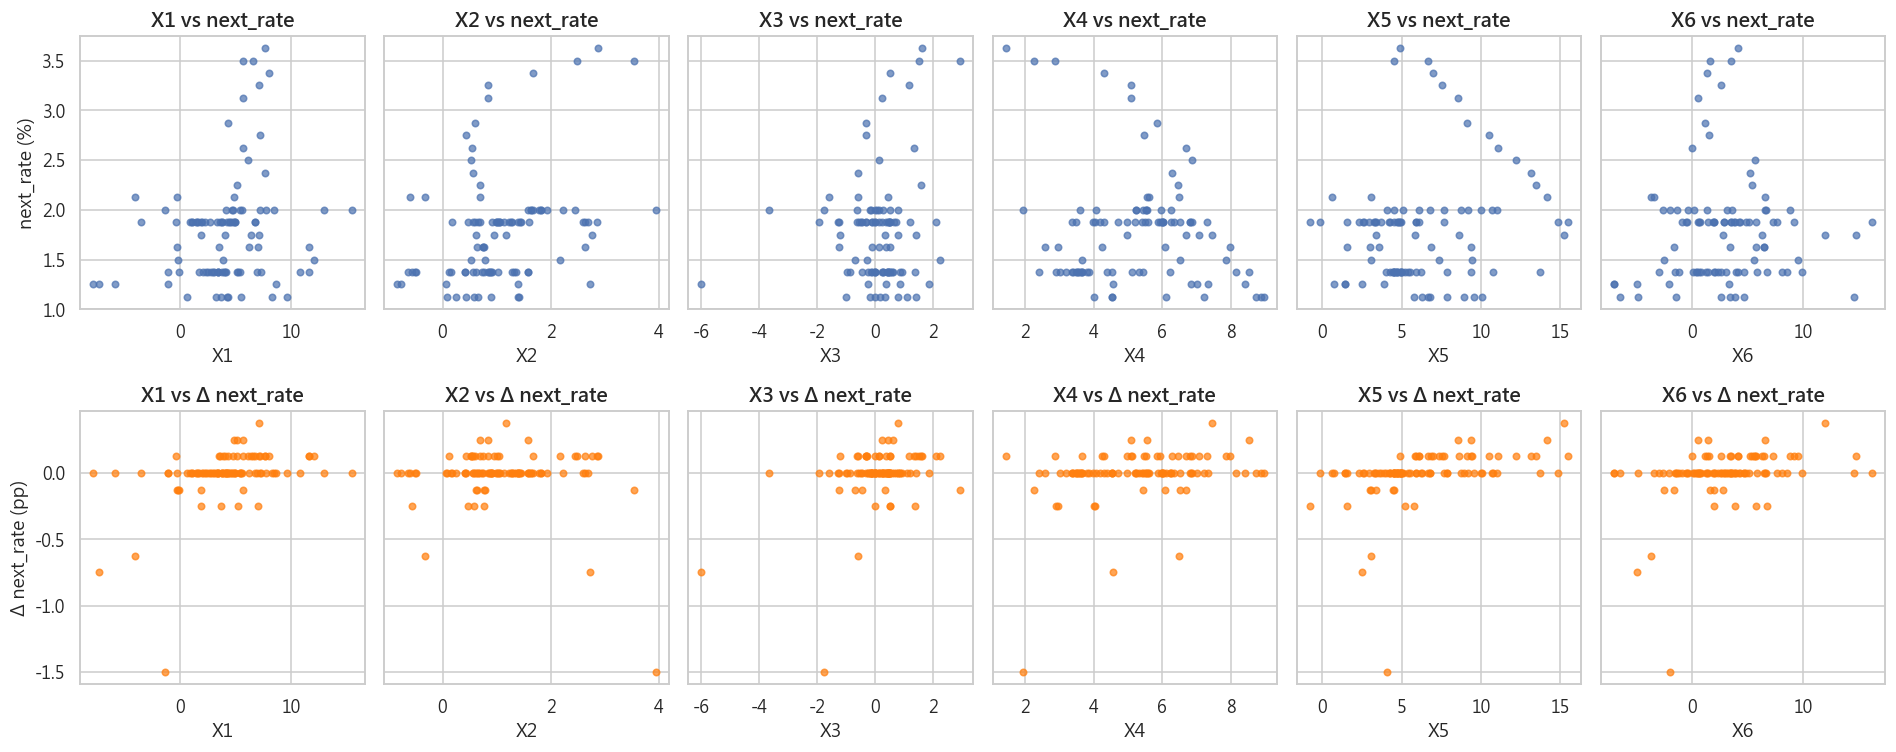

In [15]:
_n = len(BASE_X)
fig, axes = plt.subplots(2, _n, figsize=(2.9 * _n, 7), sharey="row")
for j, c in enumerate(BASE_X):
    axes[0, j].scatter(supervised[c], y_level, s=18, alpha=.7)
    axes[0, j].set_title(f"{c} vs next_rate"); axes[0, j].set_xlabel(c)
    axes[1, j].scatter(supervised[c], y_change, s=18, alpha=.7, color="tab:orange")
    axes[1, j].set_title(f"{c} vs Δ next_rate"); axes[1, j].set_xlabel(c)
axes[0, 0].set_ylabel("next_rate (%)"); axes[1, 0].set_ylabel("Δ next_rate (pp)")
plt.tight_layout(); plt.show()

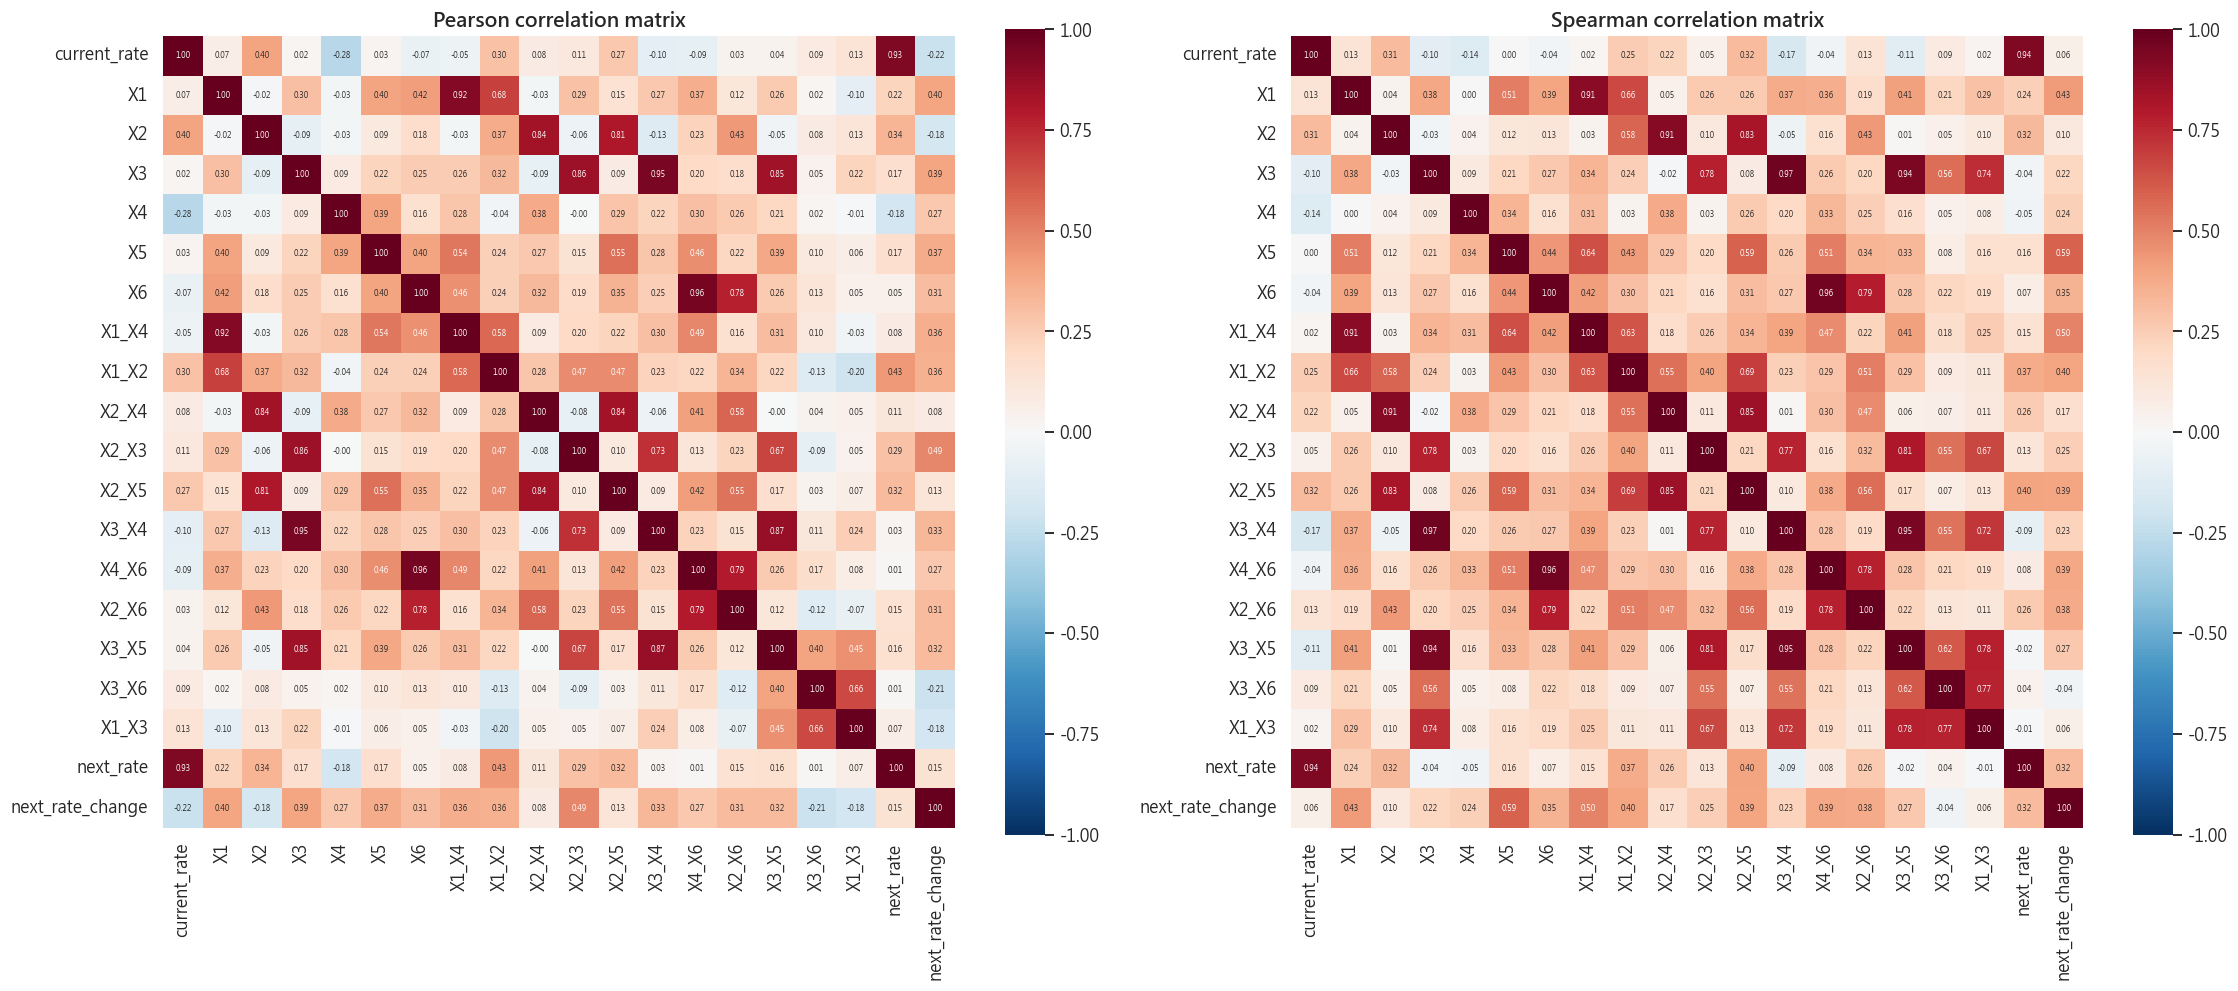

In [16]:
corr_input = supervised[["current_rate"] + BASE_X + RAW_INT + ["next_rate", "next_rate_change"]]
pear = corr_input.corr(method="pearson")
spear = corr_input.corr(method="spearman")

_N = corr_input.shape[1]
_annot = _N <= 22
fig, axes = plt.subplots(1, 2, figsize=(max(17, 1.05 * _N), max(7, 0.5 * _N)))
for ax, m, name in zip(axes, [pear, spear], ["Pearson", "Spearman"]):
    sns.heatmap(m, annot=_annot, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, cbar_kws={"shrink": .8}, ax=ax, annot_kws={"size": 5})
    ax.set_title(f"{name} correlation matrix")
plt.tight_layout(); plt.show()

**Interpretation.** Among the raw predictors, `X2` has the strongest (still modest) linear
association with the next-quarter rate; `current_rate` is by far the best single predictor of
`next_rate` (persistence). Correlations with `next_rate_change` are weak for every predictor —
turning points are genuinely hard to see one quarter ahead. The interaction columns are
strongly correlated with their parent variables (visible as deep-red blocks), which motivates
the formal multicollinearity work in Section 6. A handful of IQR "outliers" sit in
2008–2009 and 2020–2021 (GFC and pandemic) — real macro episodes, retained.

## 6. Multicollinearity Analysis

This is a core part of the study. We flag highly correlated feature pairs, compute VIFs,
check whether the shipped interaction terms are genuine products and whether **mean-centering**
them reduces collinearity, then run a transparent, priority-based VIF-reduction procedure —
**using the training block only** (the last 20% of the timeline is never touched here).

### 6.1 Highly correlated feature pairs ( |Pearson r| ≥ CORRELATION_THRESHOLD )

In [17]:
feat_pool = ["current_rate"] + BASE_X + RAW_INT
cmat = supervised[feat_pool].corr().abs()
pairs = (cmat.where(np.triu(np.ones(cmat.shape), k=1).astype(bool))
             .stack().reset_index())
pairs.columns = ["feature_1", "feature_2", "abs_pearson_r"]
high_pairs = (pairs[pairs["abs_pearson_r"] >= CORRELATION_THRESHOLD]
                .sort_values("abs_pearson_r", ascending=False)
                .reset_index(drop=True))
print(f"{len(high_pairs)} pair(s) at or above |r| = {CORRELATION_THRESHOLD}")
high_pairs

9 pair(s) at or above |r| = 0.8


,feature_1,feature_2,abs_pearson_r
0,X6,X4_X6,0.955062
1,X3,X3_X4,0.949184
2,X1,X1_X4,0.915860
3,X3_X4,X3_X5,0.870855
4,X3,X2_X3,0.856292
5,X3,X3_X5,0.849514
6,X2_X4,X2_X5,0.840026
7,X2,X2_X4,0.838941
8,X2,X2_X5,0.810925


### 6.2 Variance Inflation Factors (full raw feature set)

In [18]:
vif_full = calculate_vif(supervised[feat_pool])
vif_full["interpretation"] = vif_full["VIF"].map(vif_flag)
vif_full

,feature,VIF,interpretation
0,X3,37.777913,high (>10)
1,X1_X4,32.046497,high (>10)
2,X4_X6,30.464351,high (>10)
3,X1,29.676285,high (>10)
4,X3_X4,24.905428,high (>10)
5,X6,24.297622,high (>10)
6,X2,16.238674,high (>10)
7,X2_X5,14.916914,high (>10)
8,X2_X4,12.076732,high (>10)
9,X2_X6,10.898893,high (>10)


### 6.3 Interaction terms — are they real products, and does centering help?

In [19]:
# verify the shipped interaction columns equal the product of their parents
verify = []
for (a, b), c in zip(INT_PAIRS, RAW_INT):
    max_abs_err = float((supervised[c] - supervised[a] * supervised[b]).abs().max())
    verify.append({"interaction": c, "definition": f"{a} * {b}",
                   "max_abs_error": max_abs_err, "is_true_product": max_abs_err < 1e-6})
display(pd.DataFrame(verify))

# EDA-only centered interactions (full-sample means -> NOT for modelling, see caveat)
cent = supervised[BASE_X].copy()
cent_means = cent.mean()
centered_int = {}
for (a, b) in INT_PAIRS:
    centered_int[f"{a}_{b}_c"] = (supervised[a] - cent_means[a]) * (supervised[b] - cent_means[b])
centered_int = pd.DataFrame(centered_int, index=supervised.index)

raw_set      = supervised[["current_rate"] + BASE_X + RAW_INT]
centered_set = pd.concat([supervised[["current_rate"] + BASE_X], centered_int], axis=1)

cmp = (calculate_vif(raw_set).rename(columns={"VIF": "VIF_raw_interactions"})
       .merge(
           calculate_vif(centered_set).rename(columns={"VIF": "VIF_centered_interactions",
                                                       "feature": "feature_c"}),
           left_index=True, right_index=True, how="outer"))
print("Max |Pearson r| among interaction/parent pairs:")
print("  raw     :", round(raw_set.corr().abs().where(~np.eye(len(raw_set.columns), dtype=bool)).max().max(), 3))
print("  centered:", round(centered_set.corr().abs().where(~np.eye(len(centered_set.columns), dtype=bool)).max().max(), 3))
pd.concat([calculate_vif(raw_set).add_suffix("_raw"),
           calculate_vif(centered_set).add_suffix("_centered")], axis=1)

,interaction,definition,max_abs_error,is_true_product
0,X1_X4,X1 * X4,7.105427e-15,True
1,X1_X2,X1 * X2,3.552714e-15,True
2,X2_X4,X2 * X4,3.552714e-15,True
3,X2_X3,X2 * X3,1.776357e-15,True
4,X2_X5,X2 * X5,3.552714e-15,True
5,X3_X4,X3 * X4,3.552714e-15,True
6,X4_X6,X4 * X6,1.421085e-14,True
7,X2_X6,X2 * X6,3.552714e-15,True
8,X3_X5,X3 * X5,7.105427e-15,True
9,X3_X6,X3 * X6,3.552714e-15,True


Max |Pearson r| among interaction/parent pairs:
  raw     : 0.955
  centered: 0.768


,feature_raw,VIF_raw,feature_centered,VIF_centered
0,X3,37.777913,X3_X6_c,4.466898
1,X1_X4,32.046497,X2_X6_c,3.541346
2,X4_X6,30.464351,X3_X5_c,3.386928
3,X1,29.676285,X2_X3_c,2.865899
4,X3_X4,24.905428,X1_X2_c,2.858023
5,X6,24.297622,X1_X3_c,2.819281
6,X2,16.238674,X6,2.638892
7,X2_X5,14.916914,X4_X6_c,2.614354
8,X2_X4,12.076732,X3_X4_c,2.385342
9,X2_X6,10.898893,X1_X4_c,2.358938


> **Leakage caveat.** The centered interactions above use the **full-sample** mean and are
> shown for EDA only. In the modelling pipelines (Section 7+) centering is done by a
> transformer that learns the mean **inside each training fold**, so no validation/test
> information leaks in.

### 6.4 Priority-based VIF reduction (training block only)

In [20]:
n_total   = len(supervised)
n_test    = int(round(n_total * TEST_SIZE_RATIO))
train_idx = np.arange(0, n_total - n_test)
test_idx  = np.arange(n_total - n_test, n_total)
print(f"Training block: rows 0..{train_idx[-1]}  "
      f"({supervised['quarter_label'].iloc[0]} -> {supervised['quarter_label'].iloc[train_idx[-1]]}), n={len(train_idx)}")
print(f"Holdout block : rows {test_idx[0]}..{test_idx[-1]}  "
      f"({supervised['quarter_label'].iloc[test_idx[0]]} -> {supervised['quarter_label'].iloc[-1]}), n={len(test_idx)}")

PROTECTED = ["current_rate"] + BASE_X   # never dropped: needed + economically interpretable

def reduce_by_vif(X: pd.DataFrame, protected: list[str],
                  threshold: float = VIF_THRESHOLD) -> tuple[list[str], pd.DataFrame]:
    """Iteratively drop the highest-VIF *non-protected* column until all such columns
    are below `threshold`. Returns (kept_columns, removal_log)."""
    cols, log = list(X.columns), []
    while True:
        v = calculate_vif(X[cols]).set_index("feature")["VIF"]
        droppable = v.drop(index=[c for c in protected if c in v.index], errors="ignore")
        if droppable.empty or droppable.max() < threshold:
            break
        victim = droppable.idxmax()
        log.append({"step": len(log) + 1, "removed": victim,
                    "VIF_before": round(float(droppable.max()), 2),
                    "reason": "highest VIF among non-protected (interaction / redundant)"})
        cols.remove(victim)
    return cols, pd.DataFrame(log)

X_train_raw = X_all.iloc[train_idx][["current_rate"] + BASE_X + RAW_INT]
kept_D, vif_log = reduce_by_vif(X_train_raw, PROTECTED)

print("\nVIF-reduction log (training data only):")
display(vif_log if len(vif_log) else pd.DataFrame([{"note": "no column exceeded the VIF threshold"}]))
print("Kept for Feature Set D:", kept_D)
print("\nVIF after reduction:")
display(calculate_vif(X_train_raw[kept_D]).assign(interpretation=lambda d: d["VIF"].map(vif_flag)))

Training block: rows 0..78  (2001Q3 -> 2021Q1), n=79
Holdout block : rows 79..98  (2021Q2 -> 2026Q1), n=20



VIF-reduction log (training data only):


,step,removed,VIF_before,reason
0,1,X4_X6,45.73,highest VIF among non-protected (interaction /...
1,2,X3_X4,33.87,highest VIF among non-protected (interaction /...
2,3,X2_X5,19.95,highest VIF among non-protected (interaction /...
3,4,X1_X4,16.53,highest VIF among non-protected (interaction /...
4,5,X1_X2,14.94,highest VIF among non-protected (interaction /...


Kept for Feature Set D: ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X2_X4', 'X2_X3', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']

VIF after reduction:


,feature,VIF,interpretation
0,X3,9.527420,watch (5-10)
1,X2,8.110700,watch (5-10)
2,X3_X5,7.760471,watch (5-10)
3,X3_X6,6.754059,watch (5-10)
4,X1_X3,6.134994,watch (5-10)
5,X2_X3,5.853178,watch (5-10)
6,X2_X4,5.655167,watch (5-10)
7,X6,5.489656,watch (5-10)
8,X2_X6,4.027911,ok (<5)
9,X1,2.834451,ok (<5)


**Interpretation.** The `X<a>_X<b>` columns are exact products of their parents. Because the
feature-engineering step already keeps only **low-correlation** pairs, their VIFs start out far
milder than a naive full interaction set would — but products still sit on a different numeric
scale and can co-move with a parent, so we still (a) show that **mean-centering** the
interactions pulls VIFs down further, and (b) run a priority-based reducer that protects the
base economic predictors plus the current rate and drops only redundant interaction columns,
logging each step. Feature Set D is the resulting lower-collinearity set; all feature
selection here is confined to the training block.

## 7. Define Feature Sets

Four feature sets are compared throughout (plus an optional PCA set for linear models only —
kept supplementary because PCA destroys interpretability):

| set | contents |
|---|---|
| **A** Base | `current_rate` + all `X<n>` base predictors |
| **B** All raw | A + the low-correlation-screened interaction terms (`X<a>_X<b>`) from the FE step |
| **C** Centered interactions | A + those same interactions rebuilt from **train-fold-centered** parents |
| **D** Reduced collinearity | training-set VIF/priority reduction of B |
| **E** PCA *(supplementary)* | PCA(95% var) on standardized A — linear models only |

Every model-comparison row records which feature set it used.

In [21]:
FEATURE_SETS = {
    "A": ["current_rate"] + BASE_X,
    "B": ["current_rate"] + BASE_X + RAW_INT,
    "C": ["current_rate"] + BASE_X,          # + centered interactions added in-pipeline
    "D": kept_D,
    "E_pca": ["current_rate"] + BASE_X,      # + PCA in-pipeline
}
for k, v in FEATURE_SETS.items():
    print(f"{k:6s}: {v}")

A     : ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6']
B     : ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X1_X4', 'X1_X2', 'X2_X4', 'X2_X3', 'X2_X5', 'X3_X4', 'X4_X6', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']
C     : ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6']
D     : ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X2_X4', 'X2_X3', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']
E_pca : ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6']


## 8. Time-Series Train and Test Design

**No random splits, no shuffling.** The last ~20% of quarters are a strict **final holdout**,
never seen during model selection or tuning. The first ~80% is the training/validation block,
inside which we use an **expanding-window** `TimeSeriesSplit` (`n_splits = N_TIME_SPLITS`,
auto-reduced if the earliest fold is too small).

**All preprocessing lives inside an sklearn `Pipeline`** — column selection, train-fold
centering of interactions, `StandardScaler`, PCA, and the model — and is re-fit from scratch
on every training fold, so nothing downstream ever sees future data.

In [22]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    """Select a fixed list of columns by name (keeps a DataFrame)."""
    def __init__(self, columns): self.columns = columns          # stored unchanged (clone-safe)
    def fit(self, X, y=None): return self
    def transform(self, X): return X.loc[:, list(self.columns)].copy()
    def get_feature_names_out(self, input_features=None): return np.asarray(list(self.columns), dtype=object)


class CenteredInteractions(BaseEstimator, TransformerMixin):
    """Append interaction terms built from parent columns centered on the *fit* (train-fold) mean."""
    def __init__(self, pairs, base_cols):
        self.pairs = pairs; self.base_cols = base_cols           # stored unchanged (clone-safe)
    def fit(self, X, y=None):
        self.means_ = X.loc[:, list(self.base_cols)].mean()
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self
    def transform(self, X):
        X = X.copy()
        for a, b in self.pairs:
            X[f"{a}_{b}_c"] = (X[a] - self.means_[a]) * (X[b] - self.means_[b])
        return X
    def get_feature_names_out(self, input_features=None):
        base = list(self.feature_names_in_) if input_features is None else list(input_features)
        return np.asarray(base + [f"{a}_{b}_c" for a, b in self.pairs], dtype=object)


def build_pipeline(model, feature_set: str, needs_scaler: bool) -> Pipeline:
    steps = [("select", ColumnSelector(FEATURE_SETS["A" if feature_set in ("C", "E_pca") else feature_set]))]
    if feature_set == "C":
        steps.append(("centered_int", CenteredInteractions(INT_PAIRS, BASE_X)))
    if feature_set == "E_pca":
        steps.append(("scale", StandardScaler()))
        steps.append(("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)))
    elif needs_scaler:
        steps.append(("scale", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)


def make_time_splits(n_train_rows: int, n_splits: int = N_TIME_SPLITS) -> TimeSeriesSplit:
    usable = min(n_splits, max(2, n_train_rows // 8))
    if usable != n_splits:
        print(f"[note] reduced TimeSeriesSplit folds {n_splits} -> {usable} (small training block)")
    return TimeSeriesSplit(n_splits=usable)

tscv = make_time_splits(len(train_idx))
print("CV folds:", tscv.get_n_splits())

CV folds: 5


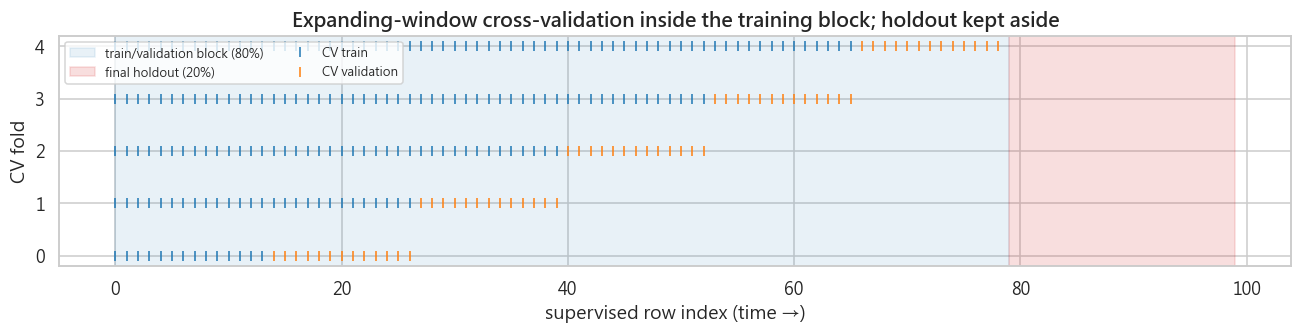

In [23]:
# visualise the split design
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axvspan(train_idx[0], train_idx[-1] + 1, color="tab:blue",  alpha=.10, label="train/validation block (80%)")
ax.axvspan(test_idx[0],  test_idx[-1] + 1,  color="tab:red",   alpha=.15, label="final holdout (20%)")
for k, (tr, va) in enumerate(tscv.split(train_idx)):
    ax.plot(tr, np.full_like(tr, k), "|", color="tab:blue")
    ax.plot(va, np.full_like(va, k), "|", color="tab:orange")
ax.plot([], [], "|", color="tab:blue", label="CV train")
ax.plot([], [], "|", color="tab:orange", label="CV validation")
ax.set_yticks(range(tscv.get_n_splits())); ax.set_ylabel("CV fold")
ax.set_xlabel("supervised row index (time →)")
ax.set_title("Expanding-window cross-validation inside the training block; holdout kept aside")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.** Each CV fold trains only on quarters that precede its validation quarters,
mimicking a true forecasting setup. Model choice and hyper-parameters are decided on these
folds alone; the red holdout block is opened exactly once, in Section 13.

## 9. Naive Baseline — persistence

$\widehat{Rate}_{t+1} = Rate_t$. Central-bank rates are very persistent, so any useful model
must beat this. We evaluate it on the CV folds and on the holdout with the same metrics.

In [24]:
def persistence_scores(idx: np.ndarray) -> dict:
    cur = cur_all.iloc[idx].to_numpy()
    act = y_level.iloc[idx].to_numpy()
    return regression_metrics(act, cur, cur)   # prediction == current rate

# CV baseline (mean over folds, on the training block)
base_folds = [persistence_scores(train_idx[va]) for _, va in tscv.split(train_idx)]
baseline_cv = pd.DataFrame(base_folds).mean().to_dict()
baseline_holdout = persistence_scores(test_idx)

print("Persistence baseline — CV mean (training block):")
for k, v in baseline_cv.items(): print(f"  {k:7s}: {v:.4f}")
print("\nPersistence baseline — final holdout:")
for k, v in baseline_holdout.items(): print(f"  {k:7s}: {v:.4f}")

Persistence baseline — CV mean (training block):
  MAE    : 0.0846
  RMSE   : 0.1517
  R2     : 0.7693
  DirAcc : 0.6154

Persistence baseline — final holdout:
  MAE    : 0.0437
  RMSE   : 0.0839
  R2     : 0.9141
  DirAcc : 0.7000


**Interpretation.** The baseline's directional accuracy equals the share of *hold* quarters
(it always predicts "no change"). Its MAE/RMSE set the bar: models are reported below as
percentage MAE/RMSE improvement over these numbers.

## 10. Candidate Models

Linear: Ordinary Linear Regression, Ridge, Lasso, Elastic Net.
Non-linear: Random Forest, Gradient Boosting, HistGradientBoosting, SVR (RBF), and XGBoost
(only if installed). **No neural networks** — the sample is far too small.

Every model predicts the **next-quarter rate level** (single target) and is run against the
feature sets that make sense for it (linear models also see the reduced-collinearity set D
and, supplementary, PCA; tree models see the full set B and the reduced set D; SVR always
with `StandardScaler`). Hyper-parameters are tuned with `GridSearchCV` over **small** grids
using `TimeSeriesSplit` (no shuffle). CV metrics in the comparison table come from a separate
expanding-window loop scored on `predicted_next_rate`.

In [25]:
def cv_predicted_rate_scores(pipe, X: pd.DataFrame, y_target: pd.Series,
                             current: pd.Series, target_kind: str,
                             splits: TimeSeriesSplit) -> dict:
    """Expanding-window CV; all folds scored on predicted next-quarter *rate*."""
    fold_metrics = []
    for tr, va in splits.split(X):
        p = clone(pipe)
        p.fit(X.iloc[tr], y_target.iloc[tr])
        pred = np.asarray(p.predict(X.iloc[va]), float)
        cur = current.iloc[va].to_numpy()
        if target_kind == "level":
            pred_next, act_next = pred, y_target.iloc[va].to_numpy()
        else:
            pred_next, act_next = cur + pred, cur + y_target.iloc[va].to_numpy()
        fold_metrics.append(regression_metrics(act_next, pred_next, cur))
    fm = pd.DataFrame(fold_metrics)
    out = {f"CV_{k}_mean": fm[k].mean() for k in fm.columns}
    out.update({f"CV_{k}_std": fm[k].std(ddof=0) for k in fm.columns})
    return out


def tune(pipe, grid: dict, X: pd.DataFrame, y: pd.Series, splits: TimeSeriesSplit):
    """GridSearchCV on RMSE (TimeSeriesSplit). Returns (best_params, fitted_best_estimator)."""
    if not grid:
        p = clone(pipe).fit(X, y)
        return {}, p
    gs = GridSearchCV(pipe, grid, scoring="neg_root_mean_squared_error",
                      cv=splits, n_jobs=1, refit=True)
    gs.fit(X, y)
    return gs.best_params_, gs.best_estimator_

In [26]:
def L(**kw):  # linear model factory entry
    kw.setdefault("needs_scaler", True)
    return dict(kind="linear", **kw)
def NL(**kw): # non-linear model factory entry
    kw.setdefault("needs_scaler", False)
    return dict(kind="nonlinear", **kw)

RUN_CONFIGS = [
    L(name="LinearRegression", make=lambda: LinearRegression(), grid={},
      feature_sets=["A", "B", "C", "D", "E_pca"]),
    L(name="Ridge", make=lambda: Ridge(random_state=RANDOM_STATE),
      grid={"model__alpha": [0.01, 0.1, 1, 10, 100]},
      feature_sets=["A", "B", "C", "D", "E_pca"]),
    L(name="Lasso", make=lambda: Lasso(random_state=RANDOM_STATE, max_iter=50000),
      grid={"model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5]},
      feature_sets=["B", "C", "D"]),
    L(name="ElasticNet", make=lambda: ElasticNet(random_state=RANDOM_STATE, max_iter=50000),
      grid={"model__alpha": [0.01, 0.1, 1.0], "model__l1_ratio": [0.2, 0.5, 0.8]},
      feature_sets=["B", "C", "D"]),
    # small ensembles + tiny grids: the sample is ~1e2 quarters, so heavy tuning would
    # only overfit; these models are included for comparison, not fine-tuned.
    NL(name="RandomForest",
       make=lambda: RandomForestRegressor(n_estimators=80, random_state=RANDOM_STATE, n_jobs=1),
       grid={"model__max_depth": [3, None]},
       feature_sets=["B", "D"]),
    NL(name="GradientBoosting",
       make=lambda: GradientBoostingRegressor(n_estimators=80, random_state=RANDOM_STATE),
       grid={"model__max_depth": [2, 3]},
       feature_sets=["B", "D"]),
    NL(name="HistGradientBoosting",
       make=lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE),
       grid={"model__max_iter": [150], "model__learning_rate": [0.05, 0.1]},
       feature_sets=["B", "D"]),
    NL(name="SVR_rbf", needs_scaler=True,
       make=lambda: SVR(kernel="rbf"),
       grid={"model__C": [1, 10, 100], "model__gamma": ["scale", 0.1, 0.01]},
       feature_sets=["A", "D"]),
]
if HAS_XGB:
    try:  # xgboost can be installed but ABI-incompatible with this sklearn; verify before use
        _probe = build_pipeline(
            XGBRegressor(n_estimators=10, verbosity=0, objective="reg:squarederror"),
            "B", False)
        _probe.fit(X_all.iloc[:20], y_level.iloc[:20])
        _ = _probe.predict(X_all.iloc[:5])
    except Exception as e:
        print(f"[note] XGBoost disabled - not compatible with this scikit-learn "
              f"({type(e).__name__}); notebook continues without it.")
        HAS_XGB = False

if HAS_XGB:
    RUN_CONFIGS.append(
        NL(name="XGBoost",
           make=lambda: XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=0,
                                     objective="reg:squarederror"),
           grid={"model__n_estimators": [200, 400], "model__max_depth": [2, 3],
                 "model__learning_rate": [0.05, 0.1]},
           feature_sets=["B", "D"]))

# single target: the next-quarter rate level
TARGET_KINDS = {"level": y_level}
n_runs = sum(len(c["feature_sets"]) * len(TARGET_KINDS) for c in RUN_CONFIGS)
print(f"{len(RUN_CONFIGS)} model types -> {n_runs} (model x feature-set) runs, target = next-quarter rate level")

[note] XGBoost disabled - not compatible with this scikit-learn (AttributeError); notebook continues without it.
8 model types -> 24 (model x feature-set) runs, target = next-quarter rate level


In [27]:
records = []
X_tr_full = X_all.iloc[train_idx]
cur_tr    = cur_all.iloc[train_idx]

t_start = time.perf_counter()
n_failed = 0
for cfg in RUN_CONFIGS:
    print(f"  running {cfg['name']} ...", flush=True)
    for fs in cfg["feature_sets"]:
        for tk, y_full in TARGET_KINDS.items():
            y_tr = y_full.iloc[train_idx]
            try:
                pipe = build_pipeline(cfg["make"](), fs, cfg["needs_scaler"])
                t0 = time.perf_counter()
                best_params, fitted = tune(pipe, cfg["grid"], X_tr_full, y_tr, tscv)
                cvm = cv_predicted_rate_scores(fitted, X_tr_full, y_tr, cur_tr, tk, tscv)
                elapsed = time.perf_counter() - t0
            except Exception as e:
                n_failed += 1
                print(f"[skip] {cfg['name']} | FS-{fs} | {tk}: {type(e).__name__}: {e}")
                continue
            records.append({
                "Model": cfg["name"], "Type": cfg["kind"], "Target": tk, "FeatureSet": fs,
                **{k: round(v, 4) for k, v in cvm.items()},
                "MAE_impr_vs_base":  round(1 - cvm["CV_MAE_mean"]  / baseline_cv["MAE"], 3),
                "RMSE_impr_vs_base": round(1 - cvm["CV_RMSE_mean"] / baseline_cv["RMSE"], 3),
                "TrainTime_s": round(elapsed, 3),
                "BestParams": best_params,
                "_fitted": fitted,
            })
print(f"done in {time.perf_counter() - t_start:.1f}s, {len(records)} runs kept, {n_failed} skipped")
results_df = pd.DataFrame(records)

  running LinearRegression ...


  running Ridge ...


  running Lasso ...


  running ElasticNet ...


  running RandomForest ...


  running GradientBoosting ...


  running HistGradientBoosting ...


  running SVR_rbf ...


done in 46.9s, 24 runs kept, 0 skipped


## 11. Evaluation Metrics and Model Comparison

Primary selection metrics: **CV RMSE** and **CV MAE** (expanding-window mean, on the
predicted-rate scale). Supplementary: $R^2$, directional accuracy, CV standard deviation
(stability), and MAE/RMSE improvement vs the persistence baseline. Directional accuracy is a
regression diagnostic only.

In [28]:
show_cols = ["Model", "Type", "FeatureSet",
             "CV_MAE_mean", "CV_MAE_std", "CV_RMSE_mean", "CV_RMSE_std",
             "CV_R2_mean", "CV_DirAcc_mean",
             "MAE_impr_vs_base", "RMSE_impr_vs_base", "TrainTime_s", "BestParams"]
comparison = (results_df[show_cols]
              .sort_values(["CV_RMSE_mean", "CV_MAE_mean"])
              .reset_index(drop=True))
print(f"Persistence baseline  CV MAE={baseline_cv['MAE']:.4f}  CV RMSE={baseline_cv['RMSE']:.4f}")
comparison.head(15)

Persistence baseline  CV MAE=0.0846  CV RMSE=0.1517


,Model,Type,FeatureSet,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_DirAcc_mean,MAE_impr_vs_base,RMSE_impr_vs_base,TrainTime_s,BestParams
0,Lasso,linear,B,0.2017,0.1655,0.2572,0.1882,0.1879,0.1231,-1.384,-0.695,0.574,{'model__alpha': 0.01}
1,Lasso,linear,D,0.2080,0.1950,0.2618,0.2198,0.1686,0.1692,-1.458,-0.726,0.546,{'model__alpha': 0.01}
2,ElasticNet,linear,D,0.2132,0.1926,0.2678,0.2192,0.1383,0.1692,-1.520,-0.765,2.398,"{'model__alpha': 0.01, 'model__l1_ratio': 0.8}"
3,ElasticNet,linear,B,0.2134,0.1756,0.2685,0.1985,0.1347,0.1385,-1.523,-0.770,1.474,"{'model__alpha': 0.01, 'model__l1_ratio': 0.8}"
4,Lasso,linear,C,0.2203,0.1975,0.2873,0.2433,0.1976,0.1231,-1.603,-0.894,1.372,{'model__alpha': 0.01}
5,ElasticNet,linear,C,0.2432,0.2022,0.3064,0.2361,-0.1081,0.0923,-1.874,-1.019,5.244,"{'model__alpha': 0.1, 'model__l1_ratio': 0.2}"
6,SVR_rbf,nonlinear,A,0.2690,0.2874,0.3283,0.3175,-0.0750,0.0615,-2.179,-1.164,1.305,"{'model__C': 100, 'model__gamma': 0.01}"
7,SVR_rbf,nonlinear,D,0.2817,0.3153,0.3335,0.3499,-0.2609,0.1538,-2.329,-1.198,1.576,"{'model__C': 100, 'model__gamma': 0.01}"
8,Ridge,linear,D,0.2908,0.2859,0.3571,0.3157,-0.4388,0.1538,-2.436,-1.354,0.524,{'model__alpha': 1}
9,Ridge,linear,A,0.2879,0.2611,0.3709,0.3018,-0.2771,0.1385,-2.402,-1.445,0.497,{'model__alpha': 1}


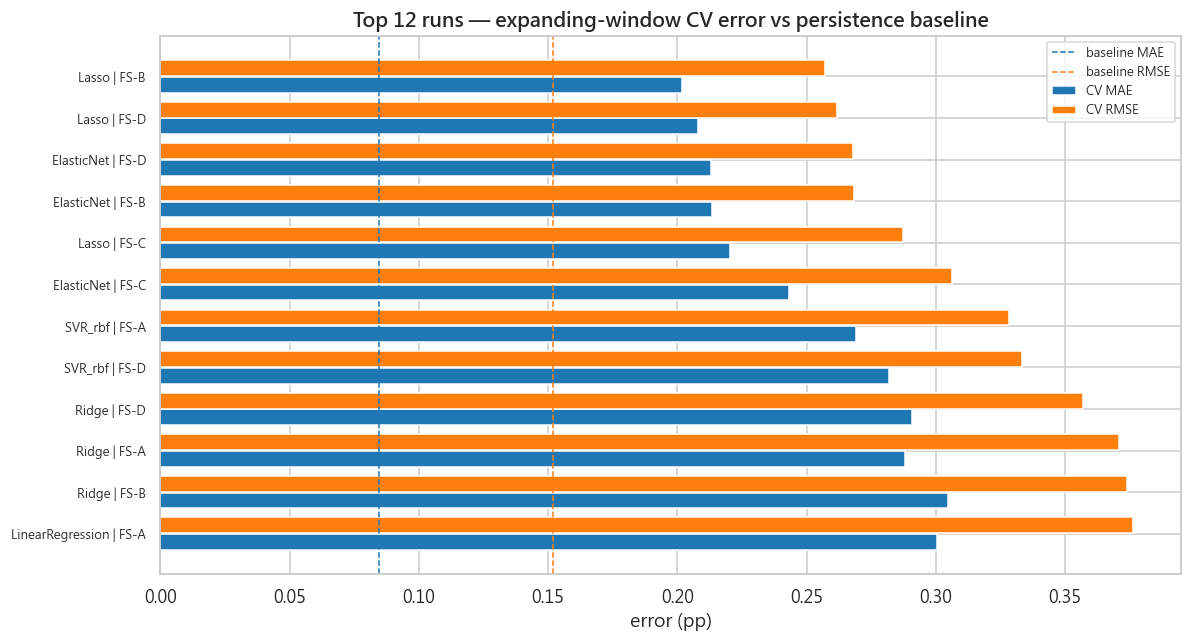

In [29]:
top = comparison.head(12).iloc[::-1]
lbl = top["Model"] + " | FS-" + top["FeatureSet"]
fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(top))
ax.barh(y - 0.2, top["CV_MAE_mean"],  height=0.38, label="CV MAE",  color="tab:blue")
ax.barh(y + 0.2, top["CV_RMSE_mean"], height=0.38, label="CV RMSE", color="tab:orange")
ax.axvline(baseline_cv["MAE"],  color="tab:blue",   ls="--", lw=1, label="baseline MAE")
ax.axvline(baseline_cv["RMSE"], color="tab:orange", ls="--", lw=1, label="baseline RMSE")
ax.set_yticks(y); ax.set_yticklabels(lbl, fontsize=8)
ax.set_xlabel("error (pp)"); ax.set_title("Top 12 runs — expanding-window CV error vs persistence baseline")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

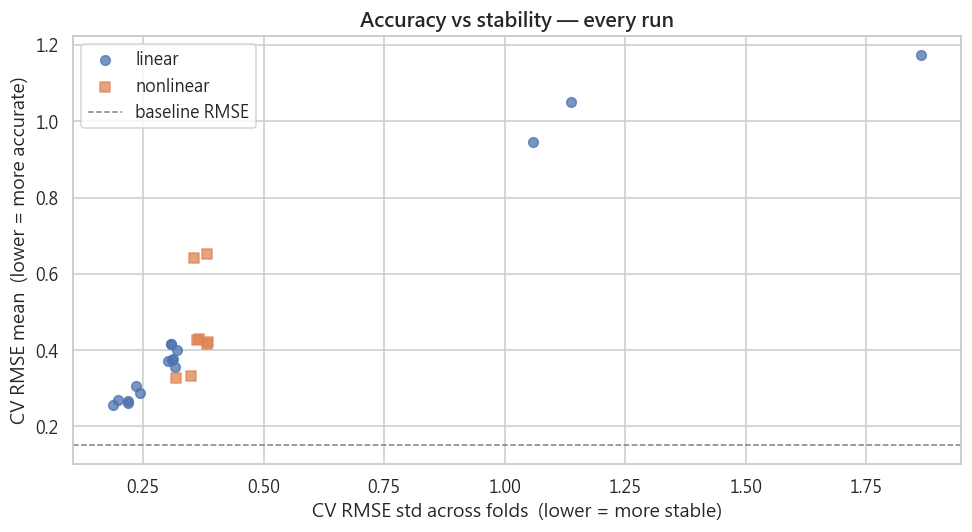

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
for t, mk in [("linear", "o"), ("nonlinear", "s")]:
    sub = results_df[results_df["Type"] == t]
    ax.scatter(sub["CV_RMSE_std"], sub["CV_RMSE_mean"], marker=mk, s=40, alpha=.75, label=t)
ax.axhline(baseline_cv["RMSE"], color="grey", ls="--", lw=1, label="baseline RMSE")
ax.set_xlabel("CV RMSE std across folds  (lower = more stable)")
ax.set_ylabel("CV RMSE mean  (lower = more accurate)")
ax.set_title("Accuracy vs stability — every run")
ax.legend()
plt.tight_layout(); plt.show()

**Interpretation.** Read the comparison table top-down (best CV RMSE first). Compare each
model against the dashed baseline lines — runs to the *left* of the baseline lines in the bar
chart are improvements. The accuracy-vs-stability scatter shows whether the lowest-error runs
are also stable across folds; with ~1e2 quarters, a slightly worse but much more stable and
interpretable model is usually the better research choice.

## 12. Select the Best Model

Selection uses **only** the training-block CV results, weighing: (1) CV RMSE, (2) CV MAE,
(3) fold stability, (4) beating the persistence baseline, (5) no obvious overfitting,
(6) interpretability, (7) behaviour across tightening cycles (checked in Section 15). If the
best non-linear run is not clearly better than the best linear run (**≥ 5% lower CV RMSE**),
we prefer the simpler, more interpretable linear model.

In [31]:
# leaderboard: every run PLUS the persistence baseline as a reference row
leaderboard = pd.concat([
    results_df[["Model", "Type", "FeatureSet",
                "CV_MAE_mean", "CV_RMSE_mean", "CV_R2_mean", "CV_DirAcc_mean"]],
    pd.DataFrame([{"Model": "PersistenceBaseline", "Type": "baseline",
                   "FeatureSet": "-",
                   "CV_MAE_mean": round(baseline_cv["MAE"], 4),
                   "CV_RMSE_mean": round(baseline_cv["RMSE"], 4),
                   "CV_R2_mean": round(baseline_cv["R2"], 4),
                   "CV_DirAcc_mean": round(baseline_cv["DirAcc"], 4)}]),
], ignore_index=True).sort_values("CV_RMSE_mean").reset_index(drop=True)
display(leaderboard.head(12))

ranked      = results_df.sort_values(["CV_RMSE_mean", "CV_MAE_mean"]).reset_index(drop=True)
best_any    = ranked.iloc[0]
best_linear = ranked[ranked["Type"] == "linear"].iloc[0]

# prefer the simpler linear model unless a non-linear one is >=5% better on CV RMSE
if best_any["Type"] == "nonlinear" and best_any["CV_RMSE_mean"] > 0.95 * best_linear["CV_RMSE_mean"]:
    chosen, reason = best_linear, "non-linear edge < 5% -> keep the simpler, interpretable linear model"
else:
    chosen, reason = best_any, "lowest CV RMSE (linear models preferred at near-equal accuracy)"

CHOSEN = chosen.to_dict()
MODEL_BEATS_BASELINE = bool(CHOSEN["CV_RMSE_mean"] < baseline_cv["RMSE"])

print(f"\nSelected model : {CHOSEN['Model']} | feature set {CHOSEN['FeatureSet']} | target = next-quarter rate level")
print(f"Params         : {CHOSEN['BestParams']}")
print(f"Reason         : {reason}")
print(f"CV  MAE={CHOSEN['CV_MAE_mean']:.4f}  RMSE={CHOSEN['CV_RMSE_mean']:.4f}  "
      f"R2={CHOSEN['CV_R2_mean']:.3f}  DirAcc={CHOSEN['CV_DirAcc_mean']:.3f}")
print(f"baseline CV     MAE={baseline_cv['MAE']:.4f}  RMSE={baseline_cv['RMSE']:.4f}")
print()
if MODEL_BEATS_BASELINE:
    print(">>> VERDICT: the selected model beats persistence on training-block CV.")
else:
    print(">>> VERDICT: NO candidate beats the persistence baseline on training-block CV.")
    print(">>> Persistence (next rate = current rate) is the recommended operational forecast.")
    print(">>> The selected model is carried forward only as a diagnostic / interpretation reference.")

# overfitting check: refit on whole training block, compare in-sample vs CV
_pipe = clone(CHOSEN["_fitted"])
_y_tr = TARGET_KINDS[CHOSEN["Target"]].iloc[train_idx]
_pipe.fit(X_tr_full, _y_tr)
_in_pred = np.asarray(_pipe.predict(X_tr_full), float)
_cur = cur_tr.to_numpy()
if CHOSEN["Target"] == "level":
    _pn, _an = _in_pred, _y_tr.to_numpy()
else:
    _pn, _an = _cur + _in_pred, _cur + _y_tr.to_numpy()
_insample = regression_metrics(_an, _pn, _cur)
print(f"\nIn-sample (training block) RMSE={_insample['RMSE']:.4f}  vs  CV RMSE={CHOSEN['CV_RMSE_mean']:.4f}  "
      f"-> gap {CHOSEN['CV_RMSE_mean'] - _insample['RMSE']:+.4f} (large positive gap = overfitting risk)")

,Model,Type,FeatureSet,CV_MAE_mean,CV_RMSE_mean,CV_R2_mean,CV_DirAcc_mean
0,PersistenceBaseline,baseline,-,0.0846,0.1517,0.7693,0.6154
1,Lasso,linear,B,0.2017,0.2572,0.1879,0.1231
2,Lasso,linear,D,0.2080,0.2618,0.1686,0.1692
3,ElasticNet,linear,D,0.2132,0.2678,0.1383,0.1692
4,ElasticNet,linear,B,0.2134,0.2685,0.1347,0.1385
5,Lasso,linear,C,0.2203,0.2873,0.1976,0.1231
6,ElasticNet,linear,C,0.2432,0.3064,-0.1081,0.0923
7,SVR_rbf,nonlinear,A,0.2690,0.3283,-0.0750,0.0615
8,SVR_rbf,nonlinear,D,0.2817,0.3335,-0.2609,0.1538
9,Ridge,linear,D,0.2908,0.3571,-0.4388,0.1538



Selected model : Lasso | feature set B | target = next-quarter rate level
Params         : {'model__alpha': 0.01}
Reason         : lowest CV RMSE (linear models preferred at near-equal accuracy)
CV  MAE=0.2017  RMSE=0.2572  R2=0.188  DirAcc=0.123
baseline CV     MAE=0.0846  RMSE=0.1517

>>> VERDICT: NO candidate beats the persistence baseline on training-block CV.
>>> Persistence (next rate = current rate) is the recommended operational forecast.
>>> The selected model is carried forward only as a diagnostic / interpretation reference.

In-sample (training block) RMSE=0.1410  vs  CV RMSE=0.2572  -> gap +0.1162 (large positive gap = overfitting risk)


**Interpretation.** The selected configuration is fixed here; hyper-parameters and feature set
are **not** changed after we look at the holdout. Read the `VERDICT` line carefully: if no
model beats the persistence baseline on training-block CV, the honest conclusion is that the
tested macro features add no one-quarter-ahead predictive value, and the operational forecast
should be persistence. The selected model is still carried through Sections 13–16 so its
behaviour, coefficients/importances and holdout error can be documented — but as a reference,
not a recommendation. The in-sample vs CV RMSE gap is a quick overfitting check.

## 13. Final Holdout Evaluation

The chosen model is fit on the **entire training block** and evaluated **once** on the
untouched final-holdout quarters, on the predicted next-quarter-rate scale, against the
persistence baseline.

In [32]:
def fit_predict_next_rate(fitted_template, target_kind, fit_idx, pred_idx):
    p = clone(fitted_template)
    y_full = TARGET_KINDS[target_kind]
    p.fit(X_all.iloc[fit_idx], y_full.iloc[fit_idx])
    raw_pred = np.asarray(p.predict(X_all.iloc[pred_idx]), float)
    cur = cur_all.iloc[pred_idx].to_numpy()
    if target_kind == "level":
        pred_next = raw_pred; act_next = y_full.iloc[pred_idx].to_numpy()
    else:
        pred_next = cur + raw_pred; act_next = cur + y_full.iloc[pred_idx].to_numpy()
    return p, pred_next, act_next, cur

final_model, hold_pred, hold_act, hold_cur = fit_predict_next_rate(
    CHOSEN["_fitted"], CHOSEN["Target"], train_idx, test_idx)

holdout_metrics = regression_metrics(hold_act, hold_pred, hold_cur)
holdout_tbl = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2", "DirAcc"],
    "chosen_model": [holdout_metrics[k] for k in ["MAE", "RMSE", "R2", "DirAcc"]],
    "persistence_baseline": [baseline_holdout[k] for k in ["MAE", "RMSE", "R2", "DirAcc"]],
}).round(4)
holdout_tbl["improvement"] = np.where(
    holdout_tbl["metric"].isin(["MAE", "RMSE"]),
    (1 - holdout_tbl["chosen_model"] / holdout_tbl["persistence_baseline"]).round(3),
    (holdout_tbl["chosen_model"] - holdout_tbl["persistence_baseline"]).round(3))
holdout_tbl

,metric,chosen_model,persistence_baseline,improvement
0,MAE,0.1191,0.0438,-1.719
1,RMSE,0.1524,0.0839,-0.816
2,R2,0.7163,0.9141,-0.198
3,DirAcc,0.3000,0.7000,-0.400


In [33]:
hold_q = supervised["quarter_label"].to_numpy()[test_idx]
pred_table = pd.DataFrame({
    "quarter": hold_q,
    "current_rate": hold_cur,
    "actual_next_rate": hold_act,
    "predicted_next_rate": hold_pred.round(4),
    "actual_change": (hold_act - hold_cur).round(4),
    "predicted_change": (hold_pred - hold_cur).round(4),
    "error": (hold_pred - hold_act).round(4),
    "actual_dir": np.sign(np.round(hold_act - hold_cur, 6)).astype(int),
    "predicted_dir": np.sign(np.round(hold_pred - hold_cur, 6)).astype(int),
})
pred_table

,quarter,current_rate,actual_next_rate,predicted_next_rate,actual_change,predicted_change,error,actual_dir,predicted_dir
0,2021Q2,1.125,1.125,1.4852,0.000,0.3602,0.3602,0,1
1,2021Q3,1.125,1.125,1.2982,0.000,0.1732,0.1732,0,1
2,2021Q4,1.125,1.375,1.3668,0.250,0.2418,-0.0082,1,1
3,2022Q1,1.375,1.500,1.7209,0.125,0.3459,0.2209,1,1
4,2022Q2,1.500,1.625,1.7482,0.125,0.2482,0.1232,1,1
5,2022Q3,1.625,1.750,1.8824,0.125,0.2574,0.1324,1,1
6,2022Q4,1.750,1.875,1.8241,0.125,0.0741,-0.0509,1,1
7,2023Q1,1.875,1.875,1.7617,0.000,-0.1133,-0.1133,0,-1
8,2023Q2,1.875,1.875,1.9414,0.000,0.0664,0.0664,0,1
9,2023Q3,1.875,1.875,2.0935,0.000,0.2185,0.2185,0,1


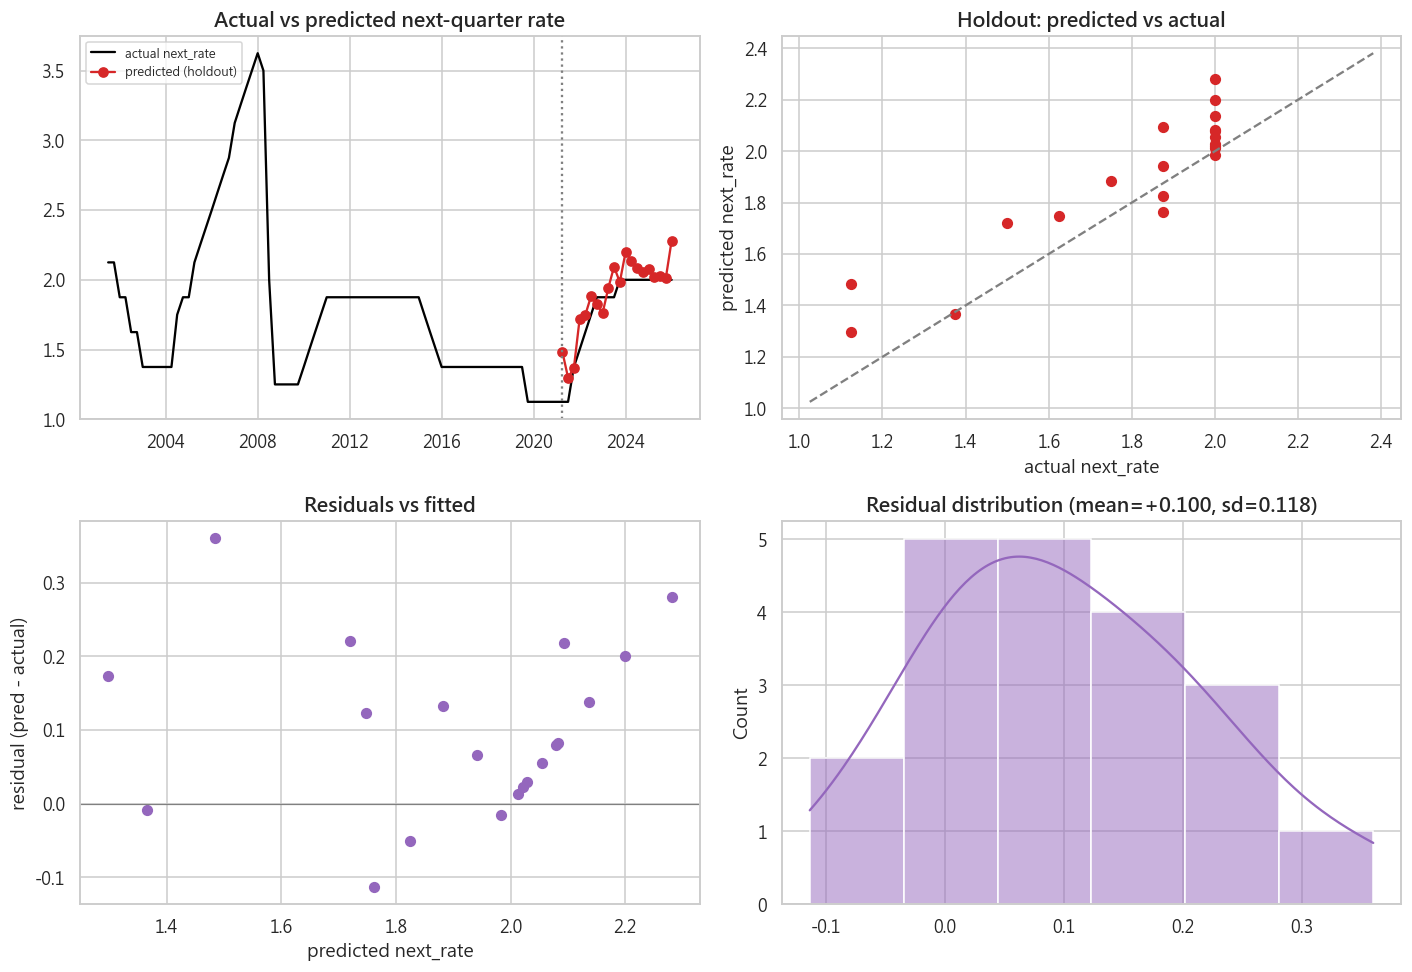

In [34]:
res = hold_pred - hold_act
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
allts = supervised["quarter"].dt.to_timestamp()
ax.plot(allts, y_level, color="black", lw=1.5, label="actual next_rate")
ax.plot(allts.to_numpy()[test_idx], hold_pred, "o-", color="tab:red", label="predicted (holdout)")
ax.axvline(allts.to_numpy()[test_idx][0], color="grey", ls=":")
ax.set_title("Actual vs predicted next-quarter rate"); ax.legend(fontsize=8)

ax = axes[0, 1]
lo = min(hold_act.min(), hold_pred.min()) - 0.1
hi = max(hold_act.max(), hold_pred.max()) + 0.1
ax.plot([lo, hi], [lo, hi], "--", color="grey")
ax.scatter(hold_act, hold_pred, s=40, color="tab:red")
ax.set_xlabel("actual next_rate"); ax.set_ylabel("predicted next_rate")
ax.set_title("Holdout: predicted vs actual")

ax = axes[1, 0]
ax.axhline(0, color="grey", lw=.8)
ax.scatter(hold_pred, res, s=40, color="tab:purple")
ax.set_xlabel("predicted next_rate"); ax.set_ylabel("residual (pred - actual)")
ax.set_title("Residuals vs fitted")

ax = axes[1, 1]
sns.histplot(res, kde=True, ax=ax, color="tab:purple")
ax.set_title(f"Residual distribution (mean={res.mean():+.3f}, sd={res.std(ddof=1):.3f})")
plt.tight_layout(); plt.show()

**Interpretation.** The holdout table and plots show whether the model tracks the recent
quarters better than "no change". With a ~20-quarter holdout that is mostly flat, expect the
MAE/RMSE edge over the baseline to be modest; the more informative check is whether the model
correctly anticipates any actual move in the holdout window (see `predicted_dir` vs
`actual_dir`). Residuals should be roughly centred with no strong pattern against fitted values.

## 14. Model Explainability

For a linear final model we report standardized coefficients (sign, magnitude, and which
variables survive L1 shrinkage). For a tree/kernel model we report **permutation importance**
(model-agnostic, computed on held-out folds) with built-in importances as a secondary view,
and a SHAP summary if `shap` is installed. Correlated features share importance, and none of
this implies causation — only predictive association.

Final model: Lasso | features into the estimator: ['current_rate', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X1_X4', 'X1_X2', 'X2_X4', 'X2_X3', 'X2_X5', 'X3_X4', 'X4_X6', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']
intercept: 1.7911392405063291
coefficients shrunk to ~0: 8/18


,feature,coef_(standardized_inputs),abs_coef
0,current_rate,0.540038,0.540038
1,X2,-0.088371,0.088371
2,X2_X3,0.062766,0.062766
3,X2_X4,0.054105,0.054105
4,X1_X2,0.048947,0.048947
5,X5,0.033481,0.033481
6,X2_X6,0.025409,0.025409
7,X1,0.022389,0.022389
8,X4_X6,-0.012048,0.012048
9,X3_X4,-0.000963,0.000963


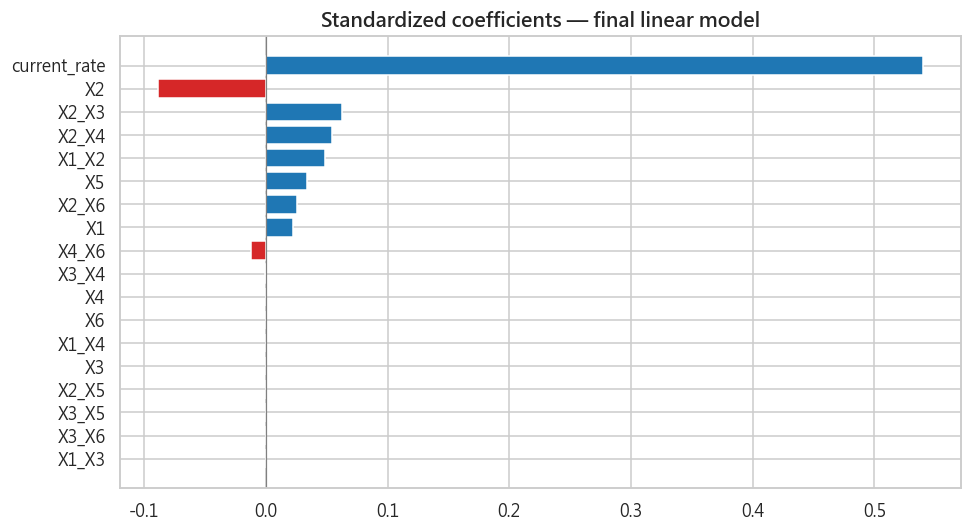

In [35]:
final_feature_names = list(final_model[:-1].get_feature_names_out())
est = final_model.named_steps["model"]
print("Final model:", CHOSEN["Model"], "| features into the estimator:", final_feature_names)

if hasattr(est, "coef_"):
    coefs = np.ravel(est.coef_)
    coef_tbl = (pd.DataFrame({"feature": final_feature_names,
                              "coef_(standardized_inputs)": coefs})
                .assign(abs_coef=lambda d: d["coef_(standardized_inputs)"].abs())
                .sort_values("abs_coef", ascending=False)
                .reset_index(drop=True))
    if hasattr(est, "intercept_"):
        print("intercept:", float(np.ravel([est.intercept_])[0]))
    n_zero = int((np.abs(coefs) < 1e-8).sum())
    print(f"coefficients shrunk to ~0: {n_zero}/{len(coefs)}")
    display(coef_tbl)

    fig, ax = plt.subplots(figsize=(9, 5))
    c = coef_tbl.iloc[::-1]
    ax.barh(c["feature"], c["coef_(standardized_inputs)"],
            color=np.where(c["coef_(standardized_inputs)"] < 0, "tab:red", "tab:blue"))
    ax.axvline(0, color="grey", lw=.8)
    ax.set_title("Standardized coefficients — final linear model")
    plt.tight_layout(); plt.show()
else:
    perm = permutation_importance(final_model, X_all.iloc[test_idx],
                                  TARGET_KINDS[CHOSEN["Target"]].iloc[test_idx],
                                  n_repeats=15, random_state=RANDOM_STATE,
                                  scoring="neg_root_mean_squared_error")
    imp_tbl = (pd.DataFrame({"feature": list(X_all.columns),   # pipeline input cols that were permuted
                             "perm_importance": perm.importances_mean,
                             "perm_std": perm.importances_std})
               .sort_values("perm_importance", ascending=False).reset_index(drop=True))
    display(imp_tbl)
    fig, ax = plt.subplots(figsize=(9, 5))
    t = imp_tbl.iloc[::-1]
    ax.barh(t["feature"], t["perm_importance"], xerr=t["perm_std"], color="tab:green")
    ax.set_title("Permutation importance (holdout, RMSE drop)")
    plt.tight_layout(); plt.show()

    if hasattr(est, "feature_importances_"):
        fi = pd.DataFrame({"feature": list(final_model[:-1].get_feature_names_out()),
                           "builtin_importance": est.feature_importances_}) \
             .sort_values("builtin_importance", ascending=False).reset_index(drop=True)
        print("Built-in importances (secondary):"); display(fi)

### 14.1 Reference linear fit (always shown)

Independent of which model was selected, this is a plain **OLS on Feature Set A** (current
rate + the base predictors) for the *direct-level* target, fit on the training block. It shows the sign and
relative weight a simple linear model puts on each variable **before** any regularisation —
useful for interpretation even when the selected model shrank everything to zero. It is a
reference, not the recommended model.

Reference OLS (FS-A, level target): R2=0.917, adj R2=0.909


,feature,std_coef,p_value,abs_coef
0,const,1.791139,3.903875e-74,1.791139
1,current_rate,0.564992,6.745887e-34,0.564992
2,X1,0.073389,2.620838e-02,0.073389
3,X3,0.065066,6.179346e-03,0.065066
4,X5,0.040684,1.408042e-01,0.040684
5,X2,-0.039117,1.313712e-01,0.039117
6,X6,-0.021955,5.005193e-01,0.021955
7,X4,0.014141,5.633909e-01,0.014141


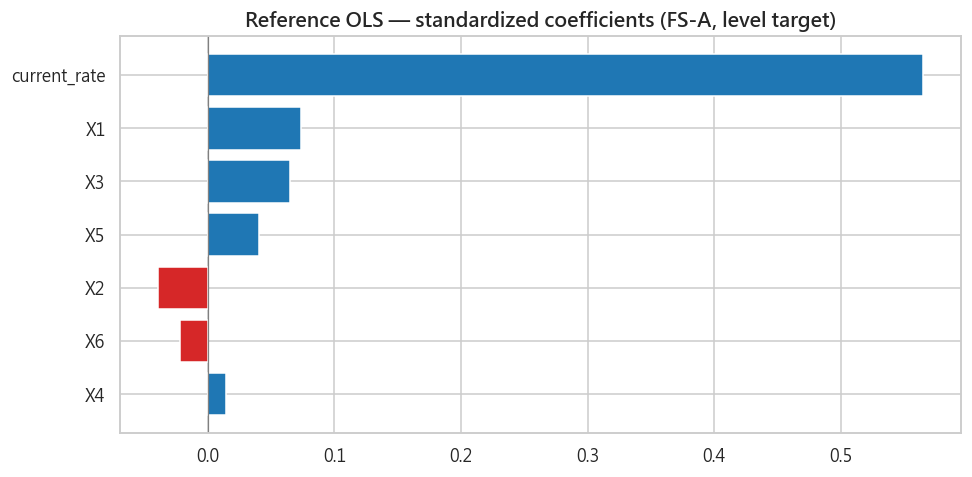

In [36]:
_Xa = X_all.iloc[train_idx][FEATURE_SETS["A"]]
_Xa_s = pd.DataFrame(StandardScaler().fit_transform(_Xa), columns=_Xa.columns)
_ols = sm.OLS(y_level.iloc[train_idx].to_numpy(), sm.add_constant(_Xa_s)).fit()
ref_coef = (pd.DataFrame({"feature": ["const"] + FEATURE_SETS["A"],
                          "std_coef": _ols.params.to_numpy(),
                          "p_value": _ols.pvalues.to_numpy()})
            .assign(abs_coef=lambda d: d["std_coef"].abs())
            .sort_values("abs_coef", ascending=False).reset_index(drop=True))
print(f"Reference OLS (FS-A, level target): R2={_ols.rsquared:.3f}, adj R2={_ols.rsquared_adj:.3f}")
display(ref_coef)

fig, ax = plt.subplots(figsize=(9, 4.5))
c = ref_coef[ref_coef["feature"] != "const"].iloc[::-1]
ax.barh(c["feature"], c["std_coef"],
        color=np.where(c["std_coef"] < 0, "tab:red", "tab:blue"))
ax.axvline(0, color="grey", lw=.8)
ax.set_title("Reference OLS — standardized coefficients (FS-A, level target)")
plt.tight_layout(); plt.show()

In [37]:
if HAS_SHAP and CHOSEN["Model"] in {"RandomForest", "GradientBoosting",
                                    "HistGradientBoosting", "XGBoost"}:
    try:
        Xte_trans = final_model[:-1].transform(X_all.iloc[test_idx])
        explainer = shap.TreeExplainer(final_model.named_steps["model"])
        sv = explainer.shap_values(Xte_trans)
        shap.summary_plot(sv, Xte_trans, show=False)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("SHAP skipped:", e)
else:
    print("SHAP not applicable to the selected model (or shap not installed).")

SHAP not applicable to the selected model (or shap not installed).


**Interpretation.** For a linear model, the sign of each standardized coefficient shows the
direction of the predictive relationship and the magnitude its relative weight; coefficients
driven to zero (Lasso/Elastic Net) mark variables the model judged redundant. For a tree
model, permutation importance shows how much holdout RMSE worsens when a feature is shuffled.
Because several predictors are collinear, importance can be *split* across a group of related
variables — a low individual score does not mean the underlying signal is unimportant.

## 15. Historical Cycle Performance

We generate **strict expanding-window out-of-sample** predictions for the whole timeline
(each quarter predicted using only earlier quarters, model re-fit each step), then measure
error inside each tightening environment. These are genuine one-step-ahead forecasts, **not**
in-sample fitted values. Each cycle has very few quarters, so this is supplementary evidence.

In [38]:
def expanding_oos(fitted_template, target_kind: str, min_train: int = 12):
    factory = lambda: clone(fitted_template)
    y_full = TARGET_KINDS[target_kind]
    idxs, preds = [], []
    for i in range(min_train, len(X_all)):
        p = factory()
        p.fit(X_all.iloc[:i], y_full.iloc[:i])
        raw = float(np.asarray(p.predict(X_all.iloc[[i]]), float)[0])
        cur_i = float(cur_all.iloc[i])
        preds.append(raw if target_kind == "level" else cur_i + raw)
        idxs.append(i)
    idxs = np.array(idxs); preds = np.array(preds)
    act = y_level.to_numpy()[idxs]
    cur = cur_all.to_numpy()[idxs]
    return pd.DataFrame({
        "row": idxs,
        "quarter": supervised["quarter_label"].to_numpy()[idxs],
        "quarter_period": supervised["quarter"].to_numpy()[idxs],
        "current_rate": cur, "actual_next_rate": act, "predicted_next_rate": preds,
        "error": preds - act,
    })

oos = expanding_oos(CHOSEN["_fitted"], CHOSEN["Target"], min_train=12)
oos_overall = regression_metrics(oos["actual_next_rate"], oos["predicted_next_rate"], oos["current_rate"])
print(f"Expanding-window OOS over {len(oos)} quarters "
      f"({oos['quarter'].iloc[0]} -> {oos['quarter'].iloc[-1]}): "
      f"MAE={oos_overall['MAE']:.4f}  RMSE={oos_overall['RMSE']:.4f}  "
      f"R2={oos_overall['R2']:.3f}  DirAcc={oos_overall['DirAcc']:.3f}")

base_oos = regression_metrics(oos["actual_next_rate"], oos["current_rate"], oos["current_rate"])
print(f"persistence over same span:            MAE={base_oos['MAE']:.4f}  RMSE={base_oos['RMSE']:.4f}  "
      f"DirAcc={base_oos['DirAcc']:.3f}")

Expanding-window OOS over 87 quarters (2004Q3 -> 2026Q1): MAE=0.1517  RMSE=0.2926  R2=0.738  DirAcc=0.218
persistence over same span:            MAE=0.0790  RMSE=0.2037  DirAcc=0.621


In [39]:
cyc_rows = []
for name, (a, b) in HIKE_ENVIRONMENTS.items():
    pa, pb = pd.Period(a, "Q"), pd.Period(b, "Q")
    m = (oos["quarter_period"] >= pa) & (oos["quarter_period"] <= pb)
    seg = oos[m]
    if len(seg) == 0:
        cyc_rows.append({"cycle": name, "n_quarters": 0}); continue
    mm = regression_metrics(seg["actual_next_rate"], seg["predicted_next_rate"], seg["current_rate"])
    bm = regression_metrics(seg["actual_next_rate"], seg["current_rate"], seg["current_rate"])
    cyc_rows.append({
        "cycle": name, "n_quarters": int(len(seg)),
        "MAE": round(mm["MAE"], 4), "RMSE": round(mm["RMSE"], 4),
        "DirAcc": round(mm["DirAcc"], 3),
        "baseline_MAE": round(bm["MAE"], 4), "baseline_RMSE": round(bm["RMSE"], 4),
        "sum_actual_change": round(float(seg["actual_next_rate"].sub(seg["current_rate"]).sum()), 3),
        "sum_pred_change":   round(float(seg["predicted_next_rate"].sub(seg["current_rate"]).sum()), 3),
    })
cycle_perf = pd.DataFrame(cyc_rows)
display(cycle_perf)

,cycle,n_quarters,MAE,RMSE,DirAcc,baseline_MAE,baseline_RMSE,sum_actual_change,sum_pred_change
0,2004-2008,18,0.3809,0.5899,0.278,0.2569,0.4259,-0.125,-2.597
1,2010-2011,8,0.0843,0.1086,0.625,0.0781,0.0988,0.625,1.057
2,2021-2023,12,0.1575,0.1916,0.417,0.0729,0.1083,0.875,1.272


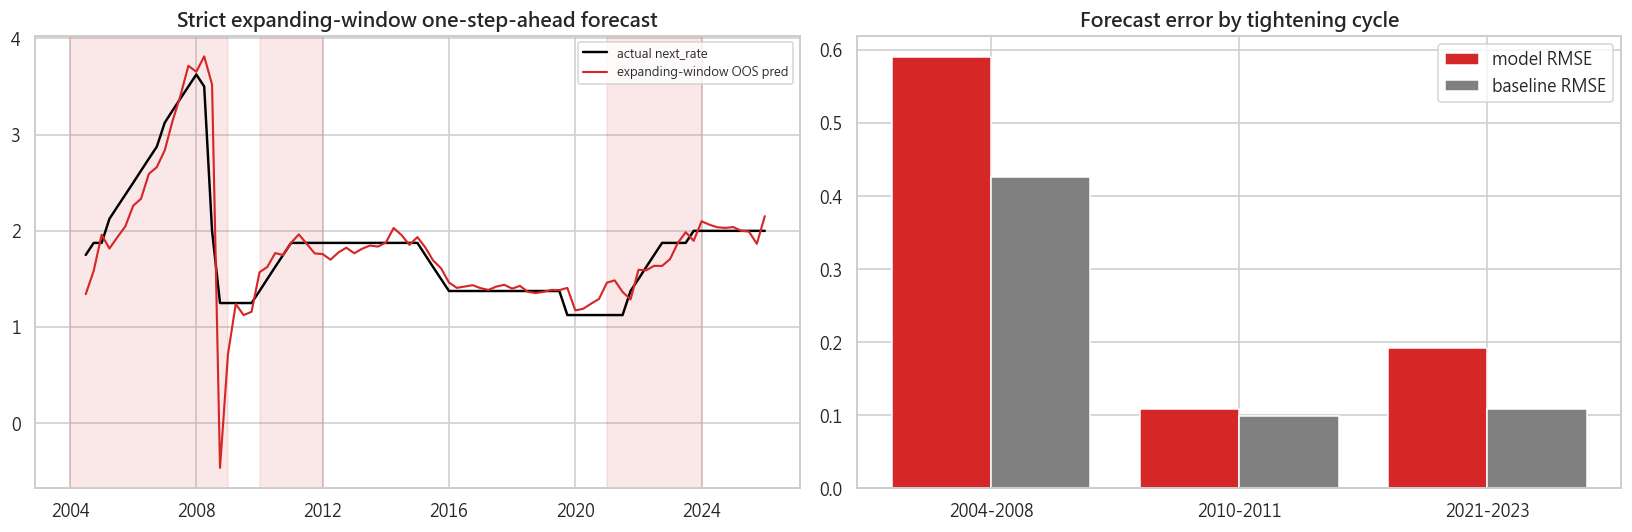

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ts = pd.PeriodIndex(oos["quarter_period"]).to_timestamp()
axes[0].plot(ts, oos["actual_next_rate"], color="black", lw=1.6, label="actual next_rate")
axes[0].plot(ts, oos["predicted_next_rate"], color="tab:red", lw=1.4, label="expanding-window OOS pred")
for name, (a, b) in HIKE_ENVIRONMENTS.items():
    axes[0].axvspan(pd.Period(a, "Q").to_timestamp(), pd.Period(b, "Q").to_timestamp(how="end"),
                    color="tab:red", alpha=.10)
axes[0].set_title("Strict expanding-window one-step-ahead forecast"); axes[0].legend(fontsize=8)

cp = cycle_perf[cycle_perf["n_quarters"] > 0]
x = np.arange(len(cp))
axes[1].bar(x - 0.2, cp["RMSE"], width=0.4, label="model RMSE", color="tab:red")
axes[1].bar(x + 0.2, cp["baseline_RMSE"], width=0.4, label="baseline RMSE", color="grey")
axes[1].set_xticks(x); axes[1].set_xticklabels(cp["cycle"]); axes[1].legend()
axes[1].set_title("Forecast error by tightening cycle")
plt.tight_layout(); plt.show()

**Interpretation.** During flat periods the model and the baseline are close. The cycle table
shows whether the model reduces error and improves directional hits when the rate is actually
moving (2004–2008 is the most informative window; 2010–2011 and 2021–2023 have only a handful
of quarters each). `sum_pred_change` vs `sum_actual_change` shows whether the model leans in
the right direction over each episode even when quarter-level timing is off. Small samples —
treat as supportive, not conclusive.

## 16. Latest Next-Quarter Forecast

The final row (no observed $Rate_{t+1}$) was excluded from training. Using the chosen model
re-fit on **all** supervised quarters and the same pipeline, we produce the genuine
next-quarter forecast. A simple **empirical** interval from expanding-window OOS residuals is
shown for context — it is *not* a probabilistic forecast, and (being a regression) we do not
output hike/cut/hold probabilities.

In [41]:
latest_q     = df["quarter"].iloc[-1]
forecast_q   = latest_q + 1
latest_feats = df[FEAT_COLS].iloc[[-1]].astype(float)
latest_cur   = float(df["current_rate"].iloc[-1])

full_model = clone(CHOSEN["_fitted"])
full_model.fit(X_all, TARGET_KINDS[CHOSEN["Target"]])
raw_fc = float(np.asarray(full_model.predict(latest_feats), float)[0])
point_fc = raw_fc if CHOSEN["Target"] == "level" else latest_cur + raw_fc

resid = (oos["predicted_next_rate"] - oos["actual_next_rate"]).to_numpy()
sd = float(np.std(resid, ddof=1))
q05, q95 = np.quantile(resid, [0.05, 0.95])

forecast = pd.DataFrame([{
    "latest_quarter": str(latest_q),
    "current_policy_rate": round(latest_cur, 4),
    "forecast_quarter": str(forecast_q),
    "persistence_forecast (recommended)": round(latest_cur, 4),
    "model_predicted_next_rate": round(point_fc, 4),
    "model_predicted_change_pp": round(point_fc - latest_cur, 4),
    "model_predicted_direction": {1: "hike", -1: "cut", 0: "hold"}[int(np.sign(round(point_fc - latest_cur, 6)))],
    "model_empirical_80pct_interval": f"[{point_fc - 1.2816 * sd:.3f}, {point_fc + 1.2816 * sd:.3f}]",
    "model_empirical_resid_quantile_interval": f"[{point_fc - abs(q05):.3f}, {point_fc + abs(q95):.3f}]",
    "model": CHOSEN["Model"],
    "target": "next-quarter rate level",
    "feature_set": CHOSEN["FeatureSet"],
    "model_beats_baseline": MODEL_BEATS_BASELINE,
}]).T.rename(columns={0: "value"})
forecast

,value
latest_quarter,2026Q2
current_policy_rate,2.0
forecast_quarter,2026Q3
persistence_forecast (recommended),2.0
model_predicted_next_rate,2.1303
model_predicted_change_pp,0.1303
model_predicted_direction,hike
model_empirical_80pct_interval,"[1.753, 2.507]"
model_empirical_resid_quantile_interval,"[1.816, 2.400]"
model,Lasso


**Interpretation.** Two numbers are shown for next quarter: the **persistence forecast**
(= current rate) and the selected **model's** point forecast. When `model_beats_baseline` is
`False` (see Section 12), the persistence number is the one to use; the model forecast is
reported for completeness and typically lands within rounding of no-change. The empirical
intervals convey the historical spread of one-step-ahead errors — typical error size, not a
calibrated probability, and there is no hike/cut/hold probability.

## 17. Final Summary

In [42]:
summary = pd.DataFrame([
    ("VERDICT",
     "model beats persistence" if MODEL_BEATS_BASELINE
     else "NO model beats persistence -> use persistence (next rate = current rate)"),
    ("Recommended next-quarter forecast",
     f"{forecast_q}: {latest_cur:.2f}% (persistence)" if not MODEL_BEATS_BASELINE
     else f"{forecast_q}: {point_fc:.3f}% ({CHOSEN['Model']})"),
    ("Best model (reference)",  CHOSEN["Model"]),
    ("Feature set",             CHOSEN["FeatureSet"]),
    ("Target",                  "next-quarter rate level (Rate_{t+1})"),
    ("Hyper-parameters",        str(CHOSEN["BestParams"])),
    ("CV MAE  (train, exp-window)",  f"{CHOSEN['CV_MAE_mean']:.4f}"),
    ("CV RMSE (train, exp-window)",  f"{CHOSEN['CV_RMSE_mean']:.4f}"),
    ("Baseline CV MAE / RMSE",       f"{baseline_cv['MAE']:.4f} / {baseline_cv['RMSE']:.4f}"),
    ("Holdout MAE / RMSE",           f"{holdout_metrics['MAE']:.4f} / {holdout_metrics['RMSE']:.4f}"),
    ("Baseline holdout MAE / RMSE",  f"{baseline_holdout['MAE']:.4f} / {baseline_holdout['RMSE']:.4f}"),
    ("Beats persistence? (CV RMSE)",  "YES" if CHOSEN["CV_RMSE_mean"] < baseline_cv["RMSE"] else "NO"),
    ("Beats persistence? (holdout RMSE)",
     "YES" if holdout_metrics["RMSE"] < baseline_holdout["RMSE"] else "NO"),
    ("Holdout directional accuracy",  f"{holdout_metrics['DirAcc']:.3f}"),
    ("Expanding-window OOS RMSE",      f"{oos_overall['RMSE']:.4f}"),
    ("Latest forecast",
     f"{forecast_q}: {point_fc:.3f}%  ({point_fc - latest_cur:+.3f} pp vs {latest_cur:.2f}%)"),
], columns=["item", "value"])
summary

,item,value
0,VERDICT,NO model beats persistence -> use persistence ...
1,Recommended next-quarter forecast,2026Q3: 2.00% (persistence)
2,Best model (reference),Lasso
3,Feature set,B
4,Target,next-quarter rate level (Rate_{t+1})
5,Hyper-parameters,{'model__alpha': 0.01}
6,"CV MAE (train, exp-window)",0.2017
7,"CV RMSE (train, exp-window)",0.2572
8,Baseline CV MAE / RMSE,0.0846 / 0.1517
9,Holdout MAE / RMSE,0.1191 / 0.1524


In [43]:
print("Top 5 runs by CV RMSE:")
display(comparison.head(5))
print("\nMost important variables in the final model (see Section 14 for the full table).")

Top 5 runs by CV RMSE:


,Model,Type,FeatureSet,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_DirAcc_mean,MAE_impr_vs_base,RMSE_impr_vs_base,TrainTime_s,BestParams
0,Lasso,linear,B,0.2017,0.1655,0.2572,0.1882,0.1879,0.1231,-1.384,-0.695,0.574,{'model__alpha': 0.01}
1,Lasso,linear,D,0.2080,0.1950,0.2618,0.2198,0.1686,0.1692,-1.458,-0.726,0.546,{'model__alpha': 0.01}
2,ElasticNet,linear,D,0.2132,0.1926,0.2678,0.2192,0.1383,0.1692,-1.520,-0.765,2.398,"{'model__alpha': 0.01, 'model__l1_ratio': 0.8}"
3,ElasticNet,linear,B,0.2134,0.1756,0.2685,0.1985,0.1347,0.1385,-1.523,-0.770,1.474,"{'model__alpha': 0.01, 'model__l1_ratio': 0.8}"
4,Lasso,linear,C,0.2203,0.1975,0.2873,0.2433,0.1976,0.1231,-1.603,-0.894,1.372,{'model__alpha': 0.01}



Most important variables in the final model (see Section 14 for the full table).


### Answers to the guiding questions

1. **Best model** — see `summary` above (`CHOSEN['Model']`), picked purely on training-block
   expanding-window CV, with a tie-break toward the simpler linear model.
2. **Feature set** — `CHOSEN['FeatureSet']` (A = base, B = +raw interactions, C = +train-centered
   interactions, D = VIF-reduced, E = PCA).
3. **Target** — the next-quarter policy-rate **level** ($Rate_{t+1}$), predicted directly
   (single formulation, per requirement — no rate-change model).
4. **CV MAE / RMSE** — in `summary`.
5. **Holdout MAE / RMSE** — in `summary`, next to the baseline values.
6. **Beats persistence?** — the two "Beats persistence?" rows (CV and holdout). Given how
   persistent Taiwan's policy rate is, any improvement is small in absolute pp terms; if the
   model does **not** clear the baseline on the holdout, that is stated plainly here.
7. **Most important variables** — Section 14 (standardized coefficients or permutation
   importance). Collinearity spreads importance across related predictors.
8. **Collinearity handling** — flagged correlated pairs (§6.1), VIF table (§6.2), showed
   mean-centering interactions cuts VIFs (§6.3), ran a protected priority-based VIF reduction
   on the training block to build Feature Set D (§6.4), and additionally leaned on
   Ridge/Lasso/Elastic Net regularisation.
9. **Cycle behaviour** — §15: error and directional hits inside 2004–2008, 2010–2011,
   2021–2023 from strict expanding-window forecasts; small samples, supportive only.
10. **Latest forecast** — §16 and `summary`: point estimate for the next quarter plus an
    empirical (non-probabilistic) error band.
11. **Limitations** — ~1e2 quarters total and only ~20 holdout quarters; the target is highly
    persistent so baselines are strong; macro releases have publication lags not modelled
    here (features are treated as known at quarter close); directional accuracy is inflated by
    the many flat quarters; even the low-correlation-screened interaction terms can still be
    somewhat collinear; no structural/regime model; the economic definitions of X1–X6 are
    documented externally, not in the data file; results
    are associational, not causal, and not investment advice.
12. **Next steps** — add a proper publication-lag / real-time vintage alignment; try
    direct multi-step (t+1…t+4) forecasts; add explicit CBC-communication or global-rate
    variables; test regime-switching or a simple Taylor-rule benchmark; expand the sample
    with monthly data; formal probabilistic intervals (quantile regression / conformal).

## 18. Appendix — Per-Period Explanatory-Power Heatmap

For every variable and every period we fit a **univariate** OLS
$Rate_{t+1} = \alpha + \beta \cdot \text{variable}_t + \varepsilon$ on the quarters inside
that period, and record the slope's **p-value**. The heatmap colour encodes
$-\log_{10}(p)$: **red = the variable is a significant one-quarter-ahead predictor in that
period, blue = not significant** (the $p = 0.05$ line is marked on the colour bar). Each cell
shows the raw p-value, and the full table is also printed underneath. Columns are the three
tightening cycles plus the full sample; a cycle with fewer than 6 quarters, or a variable
with no variation in the window, is shown as `n/a`.

Univariate (not multivariate) because the individual cycles have only ~8–20 quarters — far
too few to fit a 10-predictor model. This is a *marginal* explanatory-power view, not a
controlled one, and the tightening-cycle columns rest on very small samples.

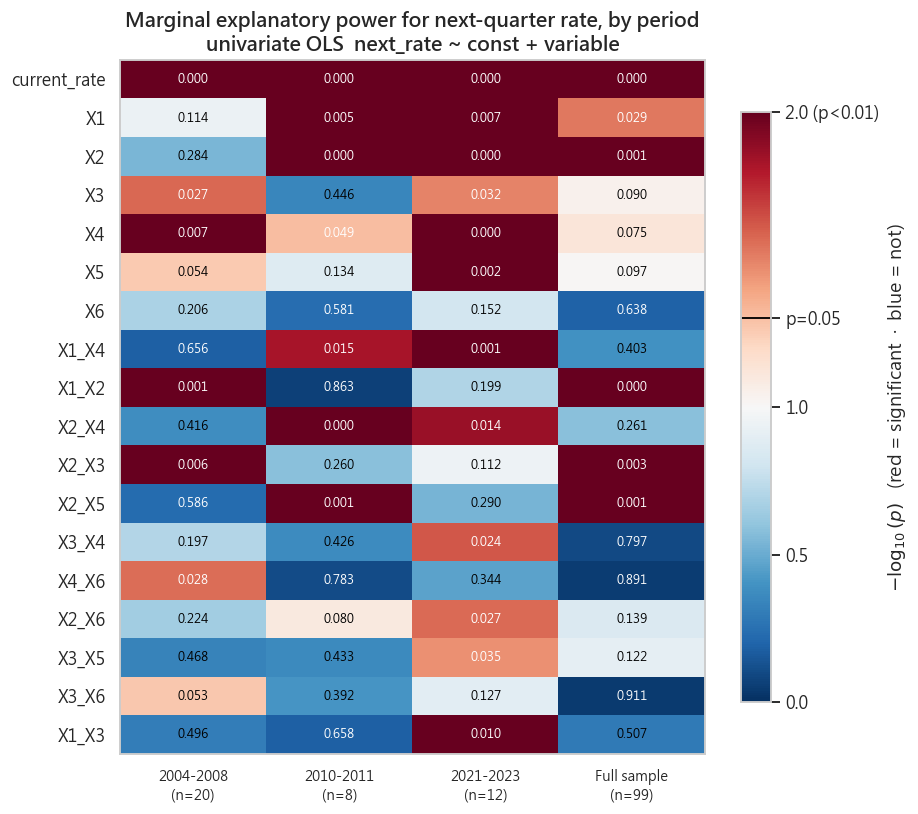

p-values (rows = variables, cols = periods):


,2004-2008,2010-2011,2021-2023,Full sample
current_rate,0.0000,0.0000,0.0000,0.0000
X1,0.1143,0.0046,0.0071,0.0295
X2,0.2840,0.0001,0.0000,0.0006
X3,0.0266,0.4462,0.0318,0.0902
X4,0.0069,0.0487,0.0000,0.0751
X5,0.0545,0.1341,0.0021,0.0967
X6,0.2064,0.5807,0.1522,0.6384
X1_X4,0.6557,0.0150,0.0012,0.4030
X1_X2,0.0007,0.8630,0.1987,0.0000
X2_X4,0.4160,0.0000,0.0137,0.2612


In [44]:
# ---- periods: 3 tightening cycles + full sample -----------------------
periods = {name: (pd.Period(a, "Q"), pd.Period(b, "Q"))
           for name, (a, b) in HIKE_ENVIRONMENTS.items()}
periods["Full sample"] = (supervised["quarter"].min(), supervised["quarter"].max())

heat_vars = FEAT_COLS   # current_rate + base predictors + interaction terms
pmat = pd.DataFrame(index=heat_vars, columns=list(periods), dtype=float)
nobs = {}
for pname, (p0, p1) in periods.items():
    m = (supervised["quarter"] >= p0) & (supervised["quarter"] <= p1)
    sub = supervised.loc[m]
    nobs[pname] = int(m.sum())
    for v in heat_vars:
        if m.sum() < 6 or float(np.std(sub[v])) < 1e-12:
            pmat.loc[v, pname] = np.nan
            continue
        ols_v = sm.OLS(sub["next_rate"].to_numpy(),
                       sm.add_constant(sub[[v]].to_numpy(), has_constant="add")).fit()
        pmat.loc[v, pname] = float(ols_v.pvalues[1])

signif = -np.log10(pmat.astype(float).clip(lower=1e-6))   # 0 (p=1) .. 6 (p<=1e-6)

fig, ax = plt.subplots(figsize=(8.5, max(6, 0.42 * len(heat_vars))))
im = ax.imshow(signif.to_numpy(dtype=float), aspect="auto", cmap="RdBu_r", vmin=0, vmax=2)
ax.set_xticks(range(len(periods)))
ax.set_xticklabels([f"{k}\n(n={nobs[k]})" for k in periods], fontsize=9)
ax.set_yticks(range(len(heat_vars)))
ax.set_yticklabels(heat_vars)
ax.grid(False)
for i, v in enumerate(heat_vars):
    for j, pname in enumerate(periods):
        p = pmat.loc[v, pname]
        val = signif.iloc[i, j]
        label = "n/a" if pd.isna(p) else f"{p:.3f}"
        colour = "white" if (pd.notna(val) and (val > 1.3 or val < 0.25)) else "black"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color=colour)
cbar = fig.colorbar(im, ax=ax, shrink=.85)
cbar.set_label(r"$-\log_{10}(p)$   (red = significant  ·  blue = not)")
cbar.ax.axhline(-np.log10(0.05), color="black", lw=1.2)
_p05 = -np.log10(0.05)
cbar.set_ticks([0.0, 0.5, 1.0, _p05, 2.0])
cbar.set_ticklabels(["0.0", "0.5", "1.0", "p=0.05", "2.0 (p<0.01)"])
ax.set_title("Marginal explanatory power for next-quarter rate, by period\n"
             "univariate OLS  next_rate ~ const + variable")
plt.tight_layout(); plt.show()

print("p-values (rows = variables, cols = periods):")
display(pmat.astype(float).round(4))

**Interpretation.** Reading across a row shows whether a variable's one-quarter-ahead signal
is stable or only shows up in particular regimes; reading down a column shows which variables
carried explanatory power during that episode. `current_rate` is expected to light up
everywhere (persistence). Any macro variable that is red in the **Full sample** column but
blue in the individual cycles is picking up cross-regime level differences rather than
within-cycle timing. Given the tiny per-cycle samples, treat the three cycle columns as
suggestive only — a single p-value from 8–20 observations is noisy.